# 서울시 골목상권 폐업위험 조기경보 — 데이터 준비와 탐색

> **핵심 질문** — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

이 노트북은 **적재 → 결합 → 라벨 → 기초 탐색 → 기준선·가설 검토** 까지를 다룸.
예측 모델링(머신러닝)은 이 노트북의 산출물을 입력으로 하는 **다음 노트북**에서 수행함.

## 분석 단위와 기간

| 항목 | 값 |
|---|---|
| 분석 단위 | 상권 × 서비스업종 × 분기 |
| 업종 범위 | 요식업 10종 |
| 기간 | 2023Q1 ~ 2025Q4 (라벨 생성을 위해 2026Q1까지 적재) |
| 라벨 | `y(t) = 1 if 개업_점포_수(t+1) − 폐업_점포_수(t+1) < 0 else 0` |

## 데이터 출처

**서울시 우리마을가게 상권분석서비스** — 서울특별시 주관 / 서울신용보증재단 위탁운영
배포: 서울 열린데이터광장 (`data.seoul.go.kr`), 공공누리 1유형

원천은 추정매출 = 신한카드 결제액 ÷ 보정비율, 유동인구 = 서울시·KT 생활인구,
점포 = 국세청 사업자등록 기반임. 이 때문에 **"폐업"은 실제 폐점이 아니라 사업자등록 말소 시점**이며,
매출은 단일 카드사 기반 추정치임. 결론을 쓸 때 해석의 폭을 이 범위로 좁힘.

## 이 노트북에서 내린 판단

1. **점포 컬럼 대응** — 연도별 파일의 `유사_업종_점포_수` = 신 기준 `전체_점포_수`,
   `점포_수` = `일반_점포_수`. `전체 = 일반 + 프랜차이즈` 항등식으로 검증함.
2. **집객시설의 빈칸은 0으로 채움** — 시설이 없는 경우를 빈칸으로 저장하는 형식임(원본에 `0` 표기 없음).
   보유율이 지나치게 낮은 항목만 제외하고 **나머지는 모두 남겨** 다음 노트북의 기여도 검토에 넘김.
3. **인구는 총량 하나만** — 유동인구가 상주·직장을 이미 포함하므로 길단위인구만 씀.
   `직장인구_비중`은 넣어 재본 뒤 판별력이 없어(단변량 AUC 0.520) 제외함.
4. **2021~2022 제외** — 방역 조치가 개·폐업을 좌우한 구간.
5. **상권변화지표의 4분면 지표는 피처가 아니라 기준선** — 폐업 정보로 만들어져 라벨과 원천이 같음.
   같은 파일의 `폐업_영업_개월_평균`도 같은 이유로 제외함.
6. **`y=0`은 두 상태의 합** — 「변화 없음」과 「변화 있었으나 줄지 않음」을 분해해 진단하되
   **표본에서 버리지 않음**. 이유는 3-1에서 상세히 다룸.
7. **`운영_영업_개월_평균`은 피처로 씀** — 상권변화지표의 재료 중 폐업 정보가 아닌 쪽임.
   상권·분기마다 값이 달라 순위에 기여할 수 있음. 판별력은 6장에서 재 봄.
8. **전국 경제지표는 넣어 보고 판정함** — 한 분기 안에서 모든 상권이 같은 값이라
   순위를 바꾸지 못한다는 것을 6장에서 수치로 확인함. 말로만 빼지 않고 확인 기록을 남김.


---
# 1. 원본 적재와 스키마 통일

In [1]:
import os, sys, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import chi2_contingency, kruskal

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

for cand in ["C:/Windows/Fonts/malgun.ttf", "/System/Library/Fonts/AppleSDGothicNeo.ttc"]:
    if Path(cand).exists():
        fm.fontManager.addfont(cand)
        plt.rcParams["font.family"] = fm.FontProperties(fname=cand).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

RAW = Path(os.environ.get(
    "SANGKWON_RAW",
    Path.home() / "OneDrive" / "바탕 화면" / "AI 데이터 인텔리전스" / "종합 과제" / "데이터"))
PROC = Path("data/processed"); PROC.mkdir(parents=True, exist_ok=True)
FIG  = Path("figures");        FIG.mkdir(parents=True, exist_ok=True)
ENC = "cp949"

Q_FEATURE = [20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244,
             20251, 20252, 20253, 20254]
Q_ALL = Q_FEATURE + [20261]          # 20261은 20254의 라벨을 만들기 위해서만 보유함
MIN_STORES = 5                        # 표본 필터 기준
TARGET_TYPE = "골목상권"

FOOD = ["한식음식점", "중식음식점", "일식음식점", "양식음식점", "분식전문점",
        "패스트푸드점", "치킨전문점", "제과점", "커피-음료", "호프-간이주점"]

print("원본 폴더:", RAW, "| 존재:", RAW.exists())
# ── 그림 글씨 크기 — 문서에 두 개가 나란히 들어가도 읽히도록 키움 ──
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 14,
})

# ── 숫자 표기 — 과학적 표기(e-) 대신 자연 실수로 씀 ──
def plain(v, max_dp=15):
    """1.23e-13 처럼 지수로 나오는 값을 0.000000000000123 형태로 바꿈"""
    if v is None: return "—"
    try: v = float(v)
    except (TypeError, ValueError): return str(v)
    if v != v: return "NaN"
    if v == 0: return "0"
    a = abs(v)
    if a >= 1e15: return f"{v:,.0f}"
    dp = max_dp if a < 1e-4 else (4 if a < 1 else 2)
    s = f"{v:,.{dp}f}"
    if "." in s: s = s.rstrip("0").rstrip(".")
    return s or "0"

pd.set_option("display.float_format", plain)


원본 폴더: C:\Users\지선호\OneDrive\바탕 화면\AI 데이터 인텔리전스\종합 과제\데이터 | 존재: True


In [2]:
FILES = {
    "store_api": "서울시 상권분석서비스(점포-상권)_API.csv",
    "sales_api": "서울시 상권분석서비스(추정매출-상권)_API.csv",
    "area":      "서울시 상권분석서비스(영역-상권).csv",
    "flow":      "서울시 상권분석서비스(길단위인구-상권).csv",
    "facility":  "서울시 상권분석서비스(집객시설-상권).csv",
    "change_ix": "서울시 상권분석서비스(상권변화지표-상권).csv",
    "macro":     "경제지표(ECOS)_월별_원본.csv",
}
for k, v in FILES.items():
    ok = (RAW/v).exists() or (RAW/(v+".gz")).exists()
    print(f"  [{'OK' if ok else '없음':>3}] {k:11} {v}")

def path(name):
    """원본은 .csv 또는 .csv.gz 어느 쪽이어도 읽음(저장소 용량 제한 때문에 gz로 보관함)"""
    for p in (RAW / name, RAW / (name + ".gz")):
        if p.exists():
            return p
    raise FileNotFoundError(f"파일 없음: {RAW / name} (.gz 포함해 찾지 못함)")

def read(name, **kw):
    return pd.read_csv(path(name), encoding=ENC, low_memory=False, **kw)

  [ OK] store_api   서울시 상권분석서비스(점포-상권)_API.csv
  [ OK] sales_api   서울시 상권분석서비스(추정매출-상권)_API.csv
  [ OK] area        서울시 상권분석서비스(영역-상권).csv
  [ OK] flow        서울시 상권분석서비스(길단위인구-상권).csv
  [ OK] facility    서울시 상권분석서비스(집객시설-상권).csv
  [ OK] change_ix   서울시 상권분석서비스(상권변화지표-상권).csv
  [ OK] macro       경제지표(ECOS)_월별_원본.csv


## 1-1. 점포-상권

Open API 통합본은 21개 분기가 하나의 스키마로 들어 있어 연도별 파일을 이어 붙일 필요가 없음.

| 2023 · 2024 | 2025~ |
|---|---|
| `유사_업종_점포_수` | `전체_점포_수` |
| `점포_수` | `일반_점포_수` |

컬럼명은 의미가 분명한 신 기준(전체 / 일반)으로 통일함.

파일이 160만 행이므로 **20만 행씩 나누어 읽으면서** 기간 필터와 요식업 필터를 바로 적용함.
밀도의 분모가 되는 `상권_전체점포`는 요식업으로 거르기 **전** 100개 업종 전체의 합이어야 하므로,
같은 순회 안에서 따로 집계함.

In [3]:
def unify_store(df):
    ren = {}
    if "유사_업종_점포_수" in df.columns: ren["유사_업종_점포_수"] = "전체_점포_수"
    if "점포_수" in df.columns:          ren["점포_수"] = "일반_점포_수"
    return df.rename(columns=ren)

STORE_COLS = ["기준_년분기_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
              "서비스_업종_코드", "서비스_업종_코드_명",
              "전체_점포_수", "일반_점포_수", "프랜차이즈_점포_수",
              "개업_점포_수", "폐업_점포_수"]

food_parts, tot_parts, n_raw, ok_n, ok_d, quarters = [], [], 0, 0, 0, set()
for chunk in pd.read_csv(path(FILES["store_api"]), encoding=ENC,
                         low_memory=False, chunksize=200_000):
    chunk = unify_store(chunk)
    n_raw += len(chunk); quarters |= set(chunk["기준_년분기_코드"].unique())
    # 항등식 검증은 원본 전체에 대해 누적함
    d_ = (chunk["전체_점포_수"] - (chunk["일반_점포_수"] + chunk["프랜차이즈_점포_수"])).abs()
    ok_n += int((d_ < 1e-6).sum()); ok_d += len(d_)
    chunk = chunk.loc[chunk["기준_년분기_코드"].isin(Q_ALL), STORE_COLS]
    tot_parts.append(chunk.groupby(["기준_년분기_코드", "상권_코드"], sort=False)["전체_점포_수"].sum())
    food_parts.append(chunk[chunk["서비스_업종_코드_명"].isin(FOOD)])
    del chunk, d_

store = pd.concat(food_parts, ignore_index=True)
tot_all = (pd.concat(tot_parts).groupby(level=[0, 1]).sum()
           .rename("상권_전체점포").reset_index())
del food_parts, tot_parts; gc.collect()

print(f"원본 {n_raw:,}행 · 분기 {len(quarters)}개 ({min(quarters)}~{max(quarters)})")
print(f"전체 = 일반 + 프랜차이즈 성립률 {ok_n/ok_d:.4%}")
assert ok_n/ok_d > 0.999, "컬럼 대응 오류 — 유사_업종_점포_수 ↔ 전체_점포_수 매칭을 확인할 것"
print(f"→ 대응 확인됨 · 기간·요식업 필터 후 {len(store):,}행 · 상권집계 {len(tot_all):,}행")

원본 1,604,844행 · 분기 21개 (20211~20261)
전체 = 일반 + 프랜차이즈 성립률 100.0000%
→ 대응 확인됨 · 기간·요식업 필터 후 160,352행 · 상권집계 21,450행


## 1-2. 나머지 테이블

`영역-상권`은 분기 개념이 없는 마스터임. 매출은 카드 결제가 잡히는 칸에만 존재해 점포보다 성김.

In [4]:
SALES_COLS = ["기준_년분기_코드", "상권_코드", "서비스_업종_코드", "당월_매출_금액", "당월_매출_건수"]
# 추정매출은 원본이 200MB 급이라 한 번에 올리면 8GB 환경에서 커밋 메모리가 부족해짐.
# 점포 파일과 같은 방식으로 나눠 읽으면서 기간 필터를 바로 적용함.
_parts = []
for _ch in pd.read_csv(path(FILES["sales_api"]), encoding=ENC, usecols=SALES_COLS,
                       low_memory=False, chunksize=200_000):
    _ch = _ch[_ch["기준_년분기_코드"].isin(Q_ALL)]
    for _c in ["당월_매출_금액", "당월_매출_건수"]:
        _ch[_c] = pd.to_numeric(_ch[_c], downcast="float")
    for _c in ["기준_년분기_코드", "상권_코드"]:            # 업종 코드는 'CS300020' 형태의 문자열임
        _ch[_c] = pd.to_numeric(_ch[_c], downcast="integer")
    _parts.append(_ch)
sales = pd.concat(_parts, ignore_index=True)
del _parts; gc.collect()
print(f"  추정매출 {len(sales):,}행 · {sales.memory_usage(deep=True).sum()/2**20:,.0f}MB")

area     = read(FILES["area"])
flow     = read(FILES["flow"], usecols=["기준_년분기_코드", "상권_코드", "총_유동인구_수"])
facility = read(FILES["facility"])
chg      = read(FILES["change_ix"])

for nm, df in [("점포(요식업)", store), ("매출", sales), ("영역", area), ("길단위인구", flow),
               ("집객시설", facility), ("상권변화지표", chg)]:
    q = df["기준_년분기_코드"].nunique() if "기준_년분기_코드" in df else 0
    print(f"  {nm:12} {len(df):>9,}행 · 상권 {df['상권_코드'].nunique():>5}개 · 분기 {q}")
_ = gc.collect()

  추정매출 282,345행 · 10MB


  점포(요식업)        160,352행 · 상권  1636개 · 분기 13
  매출             282,345행 · 상권  1587개 · 분기 13


  영역               1,650행 · 상권  1650개 · 분기 0
  길단위인구           34,633행 · 상권  1650개 · 분기 21
  집객시설            33,138행 · 상권  1578개 · 분기 21
  상권변화지표          34,650행 · 상권  1650개 · 분기 21


### 집객시설의 빈칸은 0으로 채움

집객시설 파일은 **시설이 없는 경우를 빈칸으로 저장**하는 방식임.
원본 전체에 `0` 표기가 한 건도 없다는 점으로 이를 확인함.
따라서 `지하철_역_수`가 비어 있는 것은 해당 상권에 지하철역이 없다는 뜻이므로 `fillna(0)` 으로 채움.

**어떤 항목을 남길 것인가.** 보유율(값이 1 이상인 상권 비율)이 1% 미만인 항목은
거의 모든 칸이 같은 값이라 학습에 기여할 정보가 없으므로 제외함.
그 외에는 **모두 남김.** 시설 수는 상권 규모와 함께 커지는 경향이 있어 규모의 대리변수가 되기 쉬운데,
그 판단은 눈으로 미리 하지 않고 **다음 노트북에서 기여도와 규모 상관을 함께 본 뒤** 내림.
여기서는 판단 근거가 되는 두 값을 미리 계산해 둠.

In [5]:
fac_cols = [c for c in facility.columns if c.endswith("_수")]
zero_written = int((facility[fac_cols] == 0).sum().sum())
before = facility[fac_cols].isna().mean().mean()
facility[fac_cols] = facility[fac_cols].fillna(0)
facility["역세권"] = (facility["지하철_역_수"] > 0).astype(int)
print(f"원본에 0으로 적힌 칸 {zero_written}개 → 빈칸은 결측이 아니라 '없음'을 뜻함")
print(f"집객시설 결측률 {before:.1%} → 0.0% · 역세권 상권 비율 {facility['역세권'].mean():.1%}\n")

DETAIL = [c for c in fac_cols if c != "집객시설_수"]
size_ref = facility["집객시설_수"]                     # 상권 활성도의 대리로 삼아 상관을 봄
diag = pd.DataFrame({
    "보유율":   facility[DETAIL].gt(0).mean(),
    "평균개수": facility[DETAIL].mean(),
    "규모상관": [facility[c].corr(size_ref, method="spearman")
                if facility[c].nunique() > 1 else np.nan for c in DETAIL],
}).sort_values("보유율", ascending=False)
diag["판정"] = np.where(diag["보유율"] < 0.01, "제외(정보 없음)", "유지")
display(diag.round(3))

FAC_KEEP = diag.index[diag["판정"] == "유지"].tolist()
print(f"유지 {len(FAC_KEEP)}개: {FAC_KEEP}")
print(f"제외 {len(DETAIL)-len(FAC_KEEP)}개: {[c for c in DETAIL if c not in FAC_KEEP]}")
print("\n※ 규모상관이 높은 항목도 이 단계에서는 남김. 기여도를 본 뒤 다음 노트북에서 정리함.")

원본에 0으로 적힌 칸 0개 → 빈칸은 결측이 아니라 '없음'을 뜻함
집객시설 결측률 81.2% → 0.0% · 역세권 상권 비율 12.4%



,보유율,평균개수,규모상관,판정
버스_정거장_수,0.805,3.9,0.756,유지
약국_수,0.639,2.36,0.783,유지
관공서_수,0.399,0.695,0.487,유지
은행_수,0.309,1.01,0.61,유지
지하철_역_수,0.124,0.176,0.454,유지
유치원_수,0.096,0.112,0.142,유지
숙박_시설_수,0.092,0.213,0.19,유지
일반_병원_수,0.084,0.107,0.309,유지
슈퍼마켓_수,0.067,0.102,0.042,유지
극장_수,0.053,0.072,0.273,유지


유지 12개: ['버스_정거장_수', '약국_수', '관공서_수', '은행_수', '지하철_역_수', '유치원_수', '숙박_시설_수', '일반_병원_수', '슈퍼마켓_수', '극장_수', '대학교_수', '종합병원_수']
제외 7개: ['초등학교_수', '중학교_수', '고등학교_수', '백화점_수', '공항_수', '철도_역_수', '버스_터미널_수']

※ 규모상관이 높은 항목도 이 단계에서는 남김. 기여도를 본 뒤 다음 노트북에서 정리함.


### 상권변화지표 — 지표는 기준선, 운영개월은 피처

서울시가 이미 공식으로 쓰는 4분면 진단임(`운영_영업_개월_평균`·`폐업_영업_개월_평균`을 서울 평균과 비교).

**4분면 지표 자체는 피처로 쓰지 않음.** 폐업 정보로 만들어져 우리 라벨과 원천이 같기 때문임.
모델에 넣으면 "폐업이 많아서 폐업한다"는 순환 설명이 되어 «무엇이 위험을 만드는가»가 무의미해짐.
대신 **모델이 넘어야 할 기준선**으로 5장에서 사용함.

**다만 재료 중 하나는 쓸 수 있음.** 지표를 만드는 두 값의 성격이 다름.

| 값 | 무엇으로 만들어지는가 | 판정 |
|---|---|---|
| `폐업_영업_개월_평균` | **문 닫은** 점포들의 영업 기간 | 라벨과 원천 공유 → 쓰지 않음 |
| `운영_영업_개월_평균` | **영업 중인** 점포들의 영업 기간 | 폐업 정보가 아님 → **피처로 씀** |

`운영_영업_개월_평균`은 「이 상권의 가게들이 얼마나 오래 버텄는가」이며,
값이 낮으면 최근에 새로 들어온 가게가 많다는 뜻임. 6-1에서 판별력을 재 봄.


In [6]:
IX_COLS = ["기준_년분기_코드", "상권_코드", "상권_변화_지표", "상권_변화_지표_명",
           "운영_영업_개월_평균", "폐업_영업_개월_평균",
           "서울_운영_영업_개월_평균", "서울_폐업_영업_개월_평균"]
chg = chg[IX_COLS].copy()
chg["기준선_위험"] = (chg["상권_변화_지표"] == "HL").astype(int)   # HL = 상권축소
chg["운영개월_서울대비"] = chg["운영_영업_개월_평균"] / chg["서울_운영_영업_개월_평균"]
print(chg.groupby(["상권_변화_지표", "상권_변화_지표_명"]).size().rename("건수").to_string())
print(f"\n기준선(HL) 양성률 {chg['기준선_위험'].mean():.1%}")

print("\n분기 안에서 변하는가 — 이 조건을 통과해야 상권 간 순위에 기여할 수 있음")
for c_ in ["운영_영업_개월_평균", "폐업_영업_개월_평균", "서울_운영_영업_개월_평균"]:
    n = chg.groupby("기준_년분기_코드")[c_].nunique()
    print(f"  {c_:22} 분기별 고유값 {n.min()}~{n.max()}개")
print("→ 서울 평균은 분기마다 값이 하나뿐이므로 그 자체로는 순위를 바꾸지 못함.")
print("  상권값 ÷ 서울평균 비율만 분기 간 수준 이동을 지우는 용도로 씀.")

상권_변화_지표  상권_변화_지표_명
HH        정체            11356
HL        상권축소           7597
LH        상권확장           5062
LL        다이나믹          10635

기준선(HL) 양성률 21.9%

분기 안에서 변하는가 — 이 조건을 통과해야 상권 간 순위에 기여할 수 있음
  운영_영업_개월_평균            분기별 고유값 144~156개
  폐업_영업_개월_평균            분기별 고유값 68~78개
  서울_운영_영업_개월_평균         분기별 고유값 1~1개
→ 서울 평균은 분기마다 값이 하나뿐이므로 그 자체로는 순위를 바꾸지 못함.
  상권값 ÷ 서울평균 비율만 분기 간 수준 이동을 지우는 용도로 씀.


## 1-3. 전국 경제지표 적재

두 지표를 적재함 — **음식서비스 소비자물가지수**(통계청 소비자물가조사)와
**외식비 지출전망CSI**(한국은행 소비자동향조사)임. 둘 다 전국 단위 월별 지표이므로
월 → 분기 변환은 분기 평균을 취함.

**쓸 수 있는지는 여기서 판단하지 않고 3-3 에서 다른 후보 변수와 함께 가림.**
변수를 소개하는 자리와 판정하는 자리를 나누면 흐름이 끊기므로, 적재만 하고 넘어감.


In [7]:
macro_raw = read(FILES["macro"])
macro_raw = macro_raw[macro_raw["세부명"].isna() | (macro_raw["세부명"] == "전체")]
macro_raw["기준_년분기_코드"] = (macro_raw["연월"] // 100) * 10 + (macro_raw["연월"] % 100 - 1) // 3 + 1
macro = (macro_raw.pivot_table(index="기준_년분기_코드", columns="지표", values="값", aggfunc="mean")
         .rename(columns={"음식서비스_소비자물가지수": "외식물가지수",
                          "외식비_지출전망CSI": "외식지출전망"})
         .reset_index())
macro = macro[macro["기준_년분기_코드"].isin(Q_ALL)].reset_index(drop=True)
display(macro.round(2))
print("→ 분기마다 값이 하나씩임. 상권별 값이 아니라 전국 공통 값임")

지표,기준_년분기_코드,외식지출전망,외식물가지수
0,20231,90.33,115.42
1,20232,95.67,117.32
2,20233,97.33,118.04
3,20234,93.67,118.73
4,20241,95.33,119.82
5,20242,95,120.76
6,20243,95.67,121.26
7,20244,93,122.18
8,20251,90.33,123.37
9,20252,94.33,124.57


→ 분기마다 값이 하나씩임. 상권별 값이 아니라 전국 공통 값임


## 1-4. 기간 필터

제외 근거는 표지 「이 노트북에서 내린 판단」 4번에 있음. 여기서는 필터 전후 행 수만 남김.


In [8]:
def clip_q(df, name):
    if "기준_년분기_코드" not in df.columns: return df
    n0 = len(df); out = df[df["기준_년분기_코드"].isin(Q_ALL)].copy()
    print(f"  {name:12} {n0:>9,} → {len(out):>9,}")
    return out

print("기간 필터 2023Q1~2026Q1")
flow     = clip_q(flow, "길단위인구");   facility = clip_q(facility, "집객시설")
chg      = clip_q(chg, "상권변화지표")

# 키 유일성 — 결합 전에 반드시 확인함
for nm, df, k in [("점포", store, ["기준_년분기_코드","상권_코드","서비스_업종_코드"]),
                  ("매출", sales, ["기준_년분기_코드","상권_코드","서비스_업종_코드"]),
                  ("영역", area, ["상권_코드"]),
                  ("길단위인구", flow, ["기준_년분기_코드","상권_코드"]),
                  ("집객시설", facility, ["기준_년분기_코드","상권_코드"]),
                  ("상권변화지표", chg, ["기준_년분기_코드","상권_코드"]),
                  ("경제지표", macro, ["기준_년분기_코드"])]:
    assert df.duplicated(k).sum() == 0, f"{nm} 키 중복"
print("모든 테이블의 키가 유일함")

기간 필터 2023Q1~2026Q1
  길단위인구           34,633 →    21,434
  집객시설            33,138 →    20,514
  상권변화지표          34,650 →    21,450


모든 테이블의 키가 유일함


---
# 2. 결합 — 요식업 패널 만들기

| 대상 | 결합 키 |
|---|---|
| 영역-상권 | `상권_코드` |
| 길단위인구 · 집객시설 · 상권변화지표 | `상권_코드` + `기준_년분기_코드` |
| 추정매출 | `상권_코드` + `기준_년분기_코드` + `서비스_업종_코드` |
| 경제지표 | `기준_년분기_코드` |

좌결합 후 **행 수가 늘면 키 중복**이므로 즉시 중단함. 이 단계의 최대 위험임.

In [9]:
def check(before, after, tag):
    assert after == before, f"[{tag}] 행 증식 {before:,} → {after:,}"
    print(f"  [{tag:12}] {after:,} 유지")

df = store
n = len(df)
print(f"요식업 패널 {n:,}행에 부속 정보를 붙임")
df = df.merge(area[["상권_코드", "상권_구분_코드_명", "자치구_코드_명", "행정동_코드", "행정동_코드_명",
                    "영역_면적", "엑스좌표_값", "와이좌표_값"]]
              .rename(columns={"상권_구분_코드_명": "상권유형", "자치구_코드_명": "자치구",
                               "행정동_코드_명": "행정동"}),
              on="상권_코드", how="left");                                check(n, len(df), "영역")
df = df.merge(flow, on=["기준_년분기_코드", "상권_코드"], how="left");      check(n, len(df), "길단위인구")
df = df.merge(facility[["기준_년분기_코드", "상권_코드", "역세권"] + FAC_KEEP],
              on=["기준_년분기_코드", "상권_코드"], how="left");            check(n, len(df), "집객시설")
df = df.merge(chg[["기준_년분기_코드", "상권_코드", "상권_변화_지표", "기준선_위험",
                   "운영_영업_개월_평균", "운영개월_서울대비"]],
              on=["기준_년분기_코드", "상권_코드"], how="left");            check(n, len(df), "상권변화지표")
df = df.merge(sales, on=["기준_년분기_코드", "상권_코드", "서비스_업종_코드"],
              how="left");                                              check(n, len(df), "추정매출")
df = df.merge(tot_all, on=["기준_년분기_코드", "상권_코드"], how="left");   check(n, len(df), "상권집계")
df = df.merge(macro, on="기준_년분기_코드", how="left");                   check(n, len(df), "경제지표")

# 요식업 10종 합계 — 표본 필터 이전의 전수로 계산해야 밀도가 왜곡되지 않음
food_tot = (df.groupby(["기준_년분기_코드", "상권_코드"], sort=False)["전체_점포_수"]
            .sum().rename("요식업_전체점포").reset_index())
df = df.merge(food_tot, on=["기준_년분기_코드", "상권_코드"], how="left"); check(n, len(df), "요식업집계")

del store, sales, flow; gc.collect()
print(f"\n결합 완료 {df.shape}")

# ── 메모리 축소 — 8GB 환경에서 이후 단계가 돌아가도록 dtype을 줄임 ──
def shrink(x):
    before = x.memory_usage(deep=True).sum() / 2**20
    for c_ in x.select_dtypes("float64").columns:
        x[c_] = pd.to_numeric(x[c_], downcast="float")
    for c_ in x.select_dtypes("int64").columns:
        x[c_] = pd.to_numeric(x[c_], downcast="integer")
    for c_ in x.select_dtypes("object").columns:
        if x[c_].nunique() / max(len(x), 1) < 0.5:
            x[c_] = x[c_].astype("category")
    after = x.memory_usage(deep=True).sum() / 2**20
    print(f"메모리 {before:,.0f}MB -> {after:,.0f}MB ({after/before-1:+.0%})")
    return x

df = shrink(df)
_ = gc.collect()

요식업 패널 160,352행에 부속 정보를 붙임
  [영역          ] 160,352 유지
  [길단위인구       ] 160,352 유지
  [집객시설        ] 160,352 유지


  [상권변화지표      ] 160,352 유지
  [추정매출        ] 160,352 유지
  [상권집계        ] 160,352 유지
  [경제지표        ] 160,352 유지


  [요식업집계       ] 160,352 유지

결합 완료 (160352, 42)


C:\Users\지선호\AppData\Local\Temp\ipykernel_38592\473387785.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c_ in x.select_dtypes("object").columns:


메모리 65MB -> 22MB (-66%)


## 2-1. 결측률

결측률이 높은 변수는 공변량에서 빼야 함. 표본이 통째로 날아가기 때문임.

In [10]:
cols = ["엑스좌표_값", "영역_면적", "총_유동인구_수", "역세권",
        "상권_변화_지표", "당월_매출_금액", "상권_전체점포",
        "운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망"]
miss = pd.DataFrame({"컬럼": cols, "결측률": [df[c].isna().mean() for c in cols]})
miss["판정"] = pd.cut(miss["결측률"], [-1, .05, .3, 1], labels=["OK", "주의", "공변량 제외 권장"])
miss["결측률"] = miss["결측률"].map("{:.1%}".format)
display(miss)
print("※ 매출 결측이 큰 이유는 결합 실수가 아니라, 카드 매출이 잡히지 않는 영세 칸에는 원본에 행이 없기 때문임.")
df.to_pickle(PROC / "02_merged.pkl")
print(f"[저장] 02_merged.pkl {df.shape}")

,컬럼,결측률,판정
0,엑스좌표_값,0.0%,OK
1,영역_면적,0.0%,OK
2,총_유동인구_수,0.0%,OK
3,역세권,2.3%,OK
4,상권_변화_지표,0.0%,OK
5,당월_매출_금액,45.4%,공변량 제외 권장
6,상권_전체점포,0.0%,OK
7,운영_영업_개월_평균,0.0%,OK
8,운영개월_서울대비,0.0%,OK
9,외식물가지수,0.0%,OK


※ 매출 결측이 큰 이유는 결합 실수가 아니라, 카드 매출이 잡히지 않는 영세 칸에는 원본에 행이 없기 때문임.


[저장] 02_merged.pkl (160352, 42)


---
# 3. 라벨 정의와 표본 설계

```
순증감(t) = 개업_점포_수(t) − 폐업_점포_수(t)
y(t)      = 1 if 순증감(t+1) < 0 else 0
```

두 가지를 지킴.
- `shift(-1)`은 반드시 **(상권, 업종) 그룹 내에서 분기 오름차순 정렬 후** 수행함
- 분기가 연속하지 않으면 라벨을 만들지 않음 (`20244 → 20251` 은 연속으로 처리함)

**표본 필터** — 점포 5개 미만 칸은 개·폐업이 거의 없어 라벨이 노이즈에 가까움.

In [11]:
def quarter_index(code):
    """20244 → 8099, 20251 → 8100. 연도 경계에서도 diff가 1이 되도록 함"""
    return (code // 10) * 4 + (code % 10 - 1)

df = pd.read_pickle(PROC / "02_merged.pkl")
df["분기idx"]    = quarter_index(df["기준_년분기_코드"])
df["순증감"]     = df["개업_점포_수"] - df["폐업_점포_수"]
df["순감소_현재"] = (df["순증감"] < 0).astype(int)
df["사건_현재"]   = ((df["개업_점포_수"] + df["폐업_점포_수"]) >= 1).astype(int)

df = df.sort_values(["상권_코드", "서비스_업종_코드", "분기idx"]).reset_index(drop=True)
g = df.groupby(["상권_코드", "서비스_업종_코드"], sort=False)
for src, dst in [("개업_점포_수", "다음_개업"), ("폐업_점포_수", "다음_폐업"),
                 ("분기idx", "다음분기idx")]:
    df[dst] = g[src].shift(-1)
연속 = (df["다음분기idx"] - df["분기idx"]) == 1
df.loc[~연속, ["다음_개업", "다음_폐업"]] = np.nan
has = df["다음_폐업"].notna()

df["y"] = np.nan
df.loc[has, "y"] = (df.loc[has, "다음_폐업"] > df.loc[has, "다음_개업"]).astype(int)
df["사건_다음"] = np.nan
df.loc[has, "사건_다음"] = ((df.loc[has, "다음_개업"] + df.loc[has, "다음_폐업"]) >= 1).astype(int)

print(f"라벨 생성 가능 {int(has.sum()):,} / {len(df):,}")
print(f"점포 {MIN_STORES}개 미만 {(df['전체_점포_수'] < MIN_STORES).mean():.1%}")

라벨 생성 가능 147,138 / 160,352
점포 5개 미만 54.5%


In [12]:
필터단계 = [("원본", df)]
d = df[df["y"].notna()].copy();                  필터단계.append(("라벨 존재", d))
d = d[d["전체_점포_수"] >= MIN_STORES];            필터단계.append((f"점포 {MIN_STORES}개 이상", d))
d = d[d["총_유동인구_수"].notna()];                필터단계.append(("유동인구 존재", d))
d = d[d["영역_면적"] > 0];                        필터단계.append(("면적 유효", d))

prev = None
for nm, s in 필터단계:
    print(f"  {nm:16} {len(s):>8,}" + ("" if prev is None else f"  (-{prev-len(s):,})")); prev = len(s)
d["y"] = d["y"].astype(int); d["사건_다음"] = d["사건_다음"].astype(int)
print(f"\n최종 표본 {len(d):,} · 양성률 {d['y'].mean():.1%}")
display(d.groupby("기준_년분기_코드")["y"].agg(칸수="size", 순감소율="mean").round(3))
del df; _ = gc.collect()

  원본                160,352
  라벨 존재             147,138  (-13,214)
  점포 5개 이상           67,495  (-79,643)
  유동인구 존재            67,475  (-20)
  면적 유효              67,475  (-0)

최종 표본 67,475 · 양성률 25.5%


,칸수,순감소율
기준_년분기_코드,,
20231,5706,0.229
20232,5731,0.261
20233,5701,0.223
20234,5730,0.236
20241,5706,0.254
20242,5678,0.276
20243,5622,0.262
20244,5586,0.284
20251,5534,0.261


## 3-1. `y=0` 에 무엇이 섞여 있는가

라벨은 «다음 분기에 순감소인가»만 묻기 때문에, `y=0`은 **성격이 다른 두 상태의 합**임.

| 다음 분기 상태 | 조건 | 의미 |
|---|---|---|
| **변화 없음** | 개업 = 0 **그리고** 폐업 = 0 | 문을 연 곳도, 닫은 곳도 없음 |
| **변화 있었으나 줄지 않음** | 위와 아래 어디에도 해당하지 않는 나머지 | 개·폐업은 있었으나 점포가 줄지는 않음 |
| 순감소 (`y=1`) | 폐업 > 개업 | 점포가 순수하게 빠져나감 |

«변화 있었으나 줄지 않음»은 개업 3 · 폐업 2 처럼 **오히려 늘어난 경우**까지 포함함.
`개업 − 폐업 = 0`(예: 개업 100 · 폐업 100)만이 아니라 `개업 − 폐업 > 0` 도 여기에 들어감.
`y=1`의 조건이 «폐업 > 개업» 이므로 그 나머지 전부가 이 칸이 되기 때문임.

### 상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높음

**이것이 이 라벨의 가장 큰 약점임.** 점포가 6개뿐인 골목 칸에서 한 분기 동안 아무 일도
일어나지 않는 것은 그 상권이 **안전해서가 아니라 작아서**임. 개·폐업은 점포 수에 비례해
일어나는 사건이므로, 표본이 작으면 사건 자체가 관측되지 않을 확률이 높아짐.

```
점포 6개 칸    한 분기에 개·폐업이 한 건도 없을 수 있음   →  변화 없음  →  y = 0
점포 300개 칸  한 분기에 반드시 몇 건은 일어남           →  대개 순감소 아니면 증가
```

그 결과 «변화 없음» 칸이 `y=0`에 대량으로 쌓이고, 모형은 «위험하지 않은 조건»이 아니라
**«사건이 잘 안 일어나는 조건 = 규모가 작음»** 을 학습하게 됨.
아래 규모 구간별 표에서 규모가 커질수록 «변화 없음» 비율이 떨어지고 순감소율이 올라가는 것이
그 통로를 그대로 보여 줌.

### 그러면 사건이 있었던 칸만 쓰면 되지 않는가

**쓸 수 없음.** 개업 + 폐업 ≥ 1 인 칸만 고르려면 **다음 분기의 개업·폐업 건수를 먼저 알아야** 하는데,
그 값이 바로 우리가 맞히려는 라벨임. 라벨을 봐야 표본을 만들 수 있다는 순환에 빠짐.

실제 운영에서도 성립하지 않음. 조기경보는 «다음 분기에 사건이 있을 칸» 이 아니라
**지금 존재하는 모든 상권 × 업종에 점수를 매겨야** 함. 변화 없음 칸을 미리 걷어낸 표본에서 만든
모형은 그 상황에 쓸 수 없고, 위험 확률도 실제보다 높게 나옴.

### 그래서 이렇게 함

1. 변화 없음 칸을 **버리지 않음.** 표본은 그대로 둠.
2. 대신 세 상태의 비율과, **규모에 따라 «변화 없음»이 얼마나 달라지는지** 를 측정해 남김.
3. 이 구조를 모형으로 다루는 방법 — `P(사건) × P(순감소 | 사건)` 로 나누어 푸는 2단계 모형 — 은
   다음 노트북에서 단일 모형과 **같은 검증 데이터로** 비교해 강건성 검증으로 보고함.

아래 표가 2번의 근거임.


In [13]:
S_NONE, S_FLAT, S_DROP = "변화 없음", "변화 있었으나 줄지 않음", "순감소"

상태 = pd.Series(S_FLAT, index=d.index)
상태[(d["다음_개업"] + d["다음_폐업"]) == 0] = S_NONE
상태[d["y"] == 1] = S_DROP
d["다음상태"] = 상태

t = (상태.value_counts().rename_axis("다음 분기 상태").to_frame("건수")
     .reindex([S_NONE, S_FLAT, S_DROP]))
t["비율"] = (t["건수"] / t["건수"].sum()).round(3)
display(t)
print(f"y=0 {int((d['y']==0).sum()):,}건 가운데 «{S_NONE}»이 "
      f"{(상태[d['y']==0]==S_NONE).mean():.1%} — 절반을 넘음\n")

d["규모구간"] = pd.qcut(np.log(d["전체_점포_수"]), 5, labels=False, duplicates="drop")
size_tab = (d.assign(변화없음=(상태 == S_NONE).astype(int))
            .groupby("규모구간")
            .agg(칸수=("y", "size"), 평균점포=("전체_점포_수", "mean"),
                 변화없음비율=("변화없음", "mean"), 순감소율=("y", "mean")))
size_tab.index = [f"{i+1}분위" for i in size_tab.index]
display(size_tab.round(3))

lo, hi = size_tab.iloc[0], size_tab.iloc[-1]
print(f"→ 상권 규모가 작은 곳에서 «{S_NONE}»의 빈도가 높음: "
      f"평균 점포 {lo['평균점포']:.1f}개 구간 {lo['변화없음비율']:.1%} "
      f"→ {hi['평균점포']:.1f}개 구간 {hi['변화없음비율']:.1%}")
print(f"   같은 방향으로 순감소율은 {lo['순감소율']:.1%} → {hi['순감소율']:.1%} 로 올라감.")
print("   즉 라벨이 규모에 끌려가는 통로가 «변화 없음»임. 5-2에서 규모를 고정해 이 영향을 걷어냄.")


,건수,비율
다음 분기 상태,,
변화 없음,29633,0.439
변화 있었으나 줄지 않음,20652,0.306
순감소,17190,0.255


y=0 50,285건 가운데 «변화 없음»이 58.9% — 절반을 넘음


,칸수,평균점포,변화없음비율,순감소율
1분위,15520,5.44,0.693,0.151
2분위,14018,7.86,0.599,0.193
3분위,12139,11.73,0.465,0.243
4분위,12718,19.56,0.298,0.308
5분위,13080,65.47,0.079,0.403


→ 상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높음: 평균 점포 5.4개 구간 69.3% → 65.5개 구간 7.9%
   같은 방향으로 순감소율은 15.1% → 40.3% 로 올라감.
   즉 라벨이 규모에 끌려가는 통로가 «변화 없음»임. 5-2에서 규모를 고정해 이 영향을 걷어냄.


## 3-2. 밀도와 비중 — 서로 다른 세 가지

«점포가 빽빽하다» 는 말이 여러 갈래로 갈림. 셋은 **세는 대상과 분모가 모두 달라** 전혀 다른 값이므로
이름을 나눠 둠.

먼저 헷갈리기 쉬운 이름 하나를 정리함. **`전체_점포_수`는 「상권 전체 점포」가 아님.**
「그 행 업종의 일반 + 프랜차이즈 합계」임(`전체 = 일반 + 프랜차이즈` 항등식으로 1장에서 검증함).
상권 전체는 `상권_전체점포`(100개 업종 합)이고, 요식업 10종 합은 `요식업_전체점포`임.

| 변수 | 세는 대상 | 분모 | 읽는 법 |
|---|---|---|---|
| `업종점포비중` | 그 행 업종 | 상권 전체 100업종 점포 | 이 상권이 얼마나 이 업종에 쏠려 있는가 (0~1) |
| `해당업종_점포밀도` | **그 행 업종** | 영역면적 (1만㎡) | 1만㎡ 안에 **이 업종** 점포가 몇 개인가 |
| `요식업_점포밀도` | **요식업 10종 합** | 영역면적 (1만㎡) | 1만㎡ 안에 **요식업 전체** 점포가 몇 개인가 (경쟁 강도) |

예를 들어 연남동(홍대) 96,104㎡ 상권의 한식음식점 행이라면 —

```
해당업종_점포밀도   한식음식점 18개  ÷ 9.61만㎡ =  1.9
요식업_점포밀도    요식업 10종 144개 ÷ 9.61만㎡ = 15.0
업종점포비중      18 ÷ 상권 전체 318개 = 0.057
```

**`영역_면적`의 정의는 원본에 없음.** 컬럼 설명이 제공되지 않아 확인하지 못했고,
아래 두 가지로 보아 **상업 전용 면적이 아니라 상권 경계 폴리곤 전체 면적**으로 해석함.

```
점포 1개당 면적   중앙값 420㎡ · 95분위 1,106㎡     (상업 전용이면 50~200㎡ 정도여야 함)
최대 상권 면적    2,462,734㎡ = 2.46km²
```

따라서 이 값은 **공간상의 점포 집적도**이지 상업공간의 포화도가 아님. 해석을 그 범위로 제한함.

`전체_점포_수`는 밀도와 면적의 곱으로 다시 만들어지므로, 규모를 하나의 큰 변수로 넣는 대신
**밀도 · 면적 · 비중** 세 축으로 나누어 담음. 어느 축이 위험을 만드는지 구분해 보기 위함임.


In [14]:
면적_만제곱m = d["영역_면적"] / 10000

d["업종점포비중"]    = d["전체_점포_수"] / d["상권_전체점포"]
d["해당업종_점포밀도"]   = d["전체_점포_수"] / 면적_만제곱m
d["요식업_점포밀도"] = d["요식업_전체점포"] / 면적_만제곱m
d["프랜차이즈비율"]  = d["프랜차이즈_점포_수"] / d["전체_점포_수"]
d["점포당매출"]      = d["당월_매출_금액"] / d["전체_점포_수"]
d["매출결측"]        = d["당월_매출_금액"].isna().astype(int)

d["log_점포수"]      = np.log(d["전체_점포_수"])
d["log_유동인구"]    = np.log1p(d["총_유동인구_수"])
d["log_면적"]        = np.log(d["영역_면적"])
d["log_해당업종밀도"]    = np.log1p(d["해당업종_점포밀도"])
d["log_요식업밀도"]  = np.log1p(d["요식업_점포밀도"])
d["log_점포당매출"]  = np.log1p(d["점포당매출"])
for c in FAC_KEEP:
    d["밀도_" + c.replace("_수", "")] = d[c] / 면적_만제곱m

VIEW = ["업종점포비중", "해당업종_점포밀도", "요식업_점포밀도", "log_점포수", "log_면적",
        "log_유동인구", "log_점포당매출", "프랜차이즈비율"]
display(d[VIEW].describe().loc[["mean", "std", "min", "50%", "max"]].round(3))
print(f"매출 결측 {d['매출결측'].mean():.1%} — 버리지 않고 결측 표시 변수를 함께 둠")

d.to_pickle(PROC / "03_panel.pkl")
print(f"[저장] 03_panel.pkl {d.shape}")

,업종점포비중,해당업종_점포밀도,요식업_점포밀도,log_점포수,log_면적,log_유동인구,log_점포당매출,프랜차이즈비율
mean,0.054,1.94,11.83,2.58,11.63,13.66,17,0.212
std,0.052,2.9,9.92,0.849,0.842,1.02,1.21,0.214
min,0.001,0.071,0.268,1.61,7.53,2.2,5.75,0
50%,0.036,1.07,9.63,2.4,11.7,13.81,17.19,0.158
max,0.578,55.54,170.6,6.52,14.72,15.97,21.2,1


매출 결측 7.1% — 버리지 않고 결측 표시 변수를 함께 둠


[저장] 03_panel.pkl (67475, 77)


## 3-3. 후보 변수 판정 — 새로 넣은 네 변수를 여기서 한 번에 가림

앞에서 만든 변수 중 **판별력이 확인되지 않은 네 개**를 여기서 정리함.
분석이 진행되는 중간에 변수가 새로 등장하면 해석이 끊기므로, 쓸 것과 버릴 것을
**이 자리에서 한 번에 정하고** 이후 절에서는 더 이상 새 변수를 들이지 않음.

| 변수 | 어디서 왔는가 |
|---|---|
| `운영_영업_개월_평균` | 상권변화지표 파일 — 영업 중인 점포의 평균 영업 기간 |
| `운영개월_서울대비` | 위 값을 같은 분기 서울 평균으로 나눈 것 |
| `외식물가지수` | 음식서비스 소비자물가지수 (전국 월별) |
| `외식지출전망` | 외식비 지출전망CSI (전국 월별) |

**통과해야 하는 조건이 둘임.**

| 조건 | 왜 필요한가 |
|---|---|
| **① 한 분기 안에서 값이 변하는가** | 평가가 «한 분기 안의 순위»이므로, 분기 안에서 상수인 변수는 어떤 연산을 해도 순위를 바꾸지 못함. 상수 `c` 에 대해 `c × 값` 은 `값` 의 단조 변환이라 줄 세운 결과가 같음 |
| **② 점포 수와 다른 축인가** | 이미 점포 수가 가장 센 신호임. 그것과 상관이 높으면 새 정보가 아니라 규모를 다른 이름으로 다시 넣는 것임 |

**말로 빼지 않고 값으로 판정함.** 「전국 지표는 쓸 수 없다」는 주장은 흔하지만
근거를 표로 남겨 두지 않으면 확인할 방법이 없음. 탈락한 변수도 결합 상태로 두고,
모델링 단계에서 기여도가 어떻게 나오는지까지 확인해 기록으로 남김.


In [15]:
from sklearn.metrics import roc_auc_score

CAND = ["운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망"]
REF  = ["log_점포수", "log_유동인구"]

rows = []
for c_ in CAND + REF:
    v = d[[c_, "y"]].dropna()
    auc = roc_auc_score(v["y"], v[c_])
    nq  = d.groupby("기준_년분기_코드")[c_].nunique()
    rows.append({"변수": c_,
                 "분기내 고유값": f"{nq.min()}~{nq.max()}",
                 "분기내 변동": "있음" if nq.min() > 1 else "없음(상수)",
                 "AUC": auc, "|AUC-0.5|": abs(auc - 0.5),
                 "규모상관": d[c_].corr(d["log_점포수"], method="spearman")})
cand_tab = pd.DataFrame(rows).set_index("변수")
display(cand_tab.round(3))

print("판정")
for c_, r_ in cand_tab.iterrows():
    if c_ in REF: continue
    if r_["분기내 변동"] != "있음":
        print(f"  {c_:20} 탈락 — 분기 안에서 상수라 순위에 기여할 수 없음")
    elif r_["|AUC-0.5|"] < 0.02:
        print(f"  {c_:20} 탈락 — 판별력 없음 (AUC {r_['AUC']:.3f})")
    else:
        print(f"  {c_:20} 통과 — 약하지만 방향이 있고(AUC {r_['AUC']:.3f}) "
              f"규모와 다른 축(상관 {r_['규모상관']:+.2f})")

,분기내 고유값,분기내 변동,AUC,|AUC-0.5|,규모상관
변수,,,,,
운영_영업_개월_평균,126~133,있음,0.473,0.027,-0.092
운영개월_서울대비,126~133,있음,0.468,0.032,-0.099
외식물가지수,1~1,없음(상수),0.514,0.014,0.003
외식지출전망,1~1,없음(상수),0.499,0.001,-0.003
log_점포수,188~198,있음,0.637,0.137,1
log_유동인구,1355~1378,있음,0.556,0.056,0.273


판정
  운영_영업_개월_평균          통과 — 약하지만 방향이 있고(AUC 0.473) 규모와 다른 축(상관 -0.09)
  운영개월_서울대비            통과 — 약하지만 방향이 있고(AUC 0.468) 규모와 다른 축(상관 -0.10)
  외식물가지수               탈락 — 분기 안에서 상수라 순위에 기여할 수 없음
  외식지출전망               탈락 — 분기 안에서 상수라 순위에 기여할 수 없음


In [16]:
# 통과한 변수의 5분위별 순감소율 — 단조성 확인
for c_ in ["운영_영업_개월_평균"]:
    t_ = (d.assign(_q=pd.qcut(d[c_], 5, labels=False, duplicates="drop"))
          .groupby("_q").agg(칸수=("y", "size"), 평균값=(c_, "mean"),
                             평균점포=("전체_점포_수", "mean"), 순감소율=("y", "mean")))
    t_.index = [f"{i_+1}분위" for i_ in t_.index]
    print(f"[{c_}]")
    display(t_.round(3))
    mono = t_["순감소율"].is_monotonic_increasing or t_["순감소율"].is_monotonic_decreasing
    print(f"  단조 {'예' if mono else '아니오'} · 격차 {t_['순감소율'].max()-t_['순감소율'].min():.3f}"
          f" · 구간 간 평균점포 {t_['평균점포'].min():.1f}~{t_['평균점포'].max():.1f}")
    print("  → 평균점포가 구간에 따라 크게 변하지 않으면 규모 교란이 아니라는 뜻임\n")

print("경제지표는 분기 안에서 상수이므로 5분위를 나누면 «분기를 나눈 것»과 같아져 의미가 없음.")
print("아래에서 그것을 직접 확인함.")

[운영_영업_개월_평균]


,칸수,평균값,평균점포,순감소율
1분위,14170,82.52,26.47,0.278
2분위,14210,97.22,22.68,0.266
3분위,13374,105.42,19.64,0.252
4분위,12967,114.45,17.76,0.247
5분위,12754,136.59,19.73,0.228


  단조 예 · 격차 0.050 · 구간 간 평균점포 17.8~26.5
  → 평균점포가 구간에 따라 크게 변하지 않으면 규모 교란이 아니라는 뜻임

경제지표는 분기 안에서 상수이므로 5분위를 나누면 «분기를 나눈 것»과 같아져 의미가 없음.
아래에서 그것을 직접 확인함.


In [17]:
# 경제지표가 상수라는 것의 의미 — 한 분기를 떼어 직접 확인
one_q = d[d["기준_년분기_코드"] == 20254]
print(f"2025Q4 {len(one_q):,}칸에서 각 변수가 갖는 서로 다른 값의 개수")
for c_ in ["외식물가지수", "외식지출전망", "운영_영업_개월_평균", "전체_점포_수"]:
    print(f"  {c_:20} {one_q[c_].nunique():>6}개")
print()
print("외식물가지수·외식지출전망은 5,479칸 전부가 같은 값 하나임.")
print("이 열로는 어떤 칸이 더 위험한지 구분할 수 없음 — 정렬해도 순서가 바뀌지 않기 때문임.")
print("상권 단위 변수와 곱해도 마찬가지임: 상수를 곱하는 것은 단조 변환이라 순위가 보존됨.")
print("\n분기를 가로지르면 «물가가 높은 분기에는 개업이 적은 것이 더 위험하다» 같은")
print("교호작용이 있을 수 있고, 그것은 트리 모형이 두 변수를 모두 가지면 스스로 잡음.")
print("다만 분기가 12개뿐이고 테스트가 1개 분기이므로, 테스트 분기 안의 순위는 여전히 바뀌지 않음.")

2025Q4 5,479칸에서 각 변수가 갖는 서로 다른 값의 개수
  외식물가지수                    1개
  외식지출전망                    1개
  운영_영업_개월_평균             132개
  전체_점포_수                 188개

외식물가지수·외식지출전망은 5,479칸 전부가 같은 값 하나임.
이 열로는 어떤 칸이 더 위험한지 구분할 수 없음 — 정렬해도 순서가 바뀌지 않기 때문임.
상권 단위 변수와 곱해도 마찬가지임: 상수를 곱하는 것은 단조 변환이라 순위가 보존됨.

분기를 가로지르면 «물가가 높은 분기에는 개업이 적은 것이 더 위험하다» 같은
교호작용이 있을 수 있고, 그것은 트리 모형이 두 변수를 모두 가지면 스스로 잡음.
다만 분기가 12개뿐이고 테스트가 1개 분기이므로, 테스트 분기 안의 순위는 여전히 바뀌지 않음.


---
# 4. 기초 탐색

데이터가 분석 가능한 상태인지 확인함.

In [18]:
print(f"표본 {d.shape} · 양성률 {d['y'].mean():.1%}")
display(pd.crosstab(d["서비스_업종_코드_명"], d["상권유형"]))
print("※ 관광특구는 표본이 적어 별도 결론을 내지 않음.")

표본 (67475, 77) · 양성률 25.5%


상권유형,골목상권,관광특구,발달상권,전통시장
서비스_업종_코드_명,,,,
분식전문점,3634,72,2418,1446
양식음식점,1478,72,2226,396
일식음식점,1036,72,2181,407
제과점,1636,72,2087,338
중식음식점,1207,72,1989,378
치킨전문점,1922,60,1590,614
커피-음료,7741,72,2934,1299
패스트푸드점,1440,72,2125,264
한식음식점,9957,72,2959,2689


※ 관광특구는 표본이 적어 별도 결론을 내지 않음.


In [19]:
t_type = d.groupby("상권유형")["y"].agg(칸수="size", 순감소율="mean").sort_values("순감소율")
gm = d[d["상권유형"] == TARGET_TYPE]
t_gu = (gm.groupby("자치구")["y"].agg(칸수="size", 순감소율="mean")
        .sort_values("순감소율", ascending=False))
display(t_type.round(3)); display(t_gu.round(3).head(10))

,칸수,순감소율
상권유형,,
전통시장,9121,0.224
골목상권,34647,0.236
발달상권,23011,0.292
관광특구,696,0.378


,칸수,순감소율
자치구,,
관악구,1849,0.267
강서구,1857,0.266
도봉구,1055,0.264
강동구,1735,0.252
성동구,1171,0.25
중랑구,1676,0.249
구로구,1423,0.249
동대문구,1561,0.246
강북구,1093,0.244


## 4-1. 상권유형별 차이 — 검정과 효과크기

표본이 수만 건이라 **p-value는 거의 항상 유의하게** 나옴.
실질적 차이인지는 **효과크기(Cramér's V)** 가 판정함. 둘을 반드시 함께 보고함.

In [20]:
ct = pd.crosstab(d["상권유형"], d["y"])
chi2, p, dof, _ = chi2_contingency(ct, correction=False)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"상권유형 x 순감소  chi2({dof}) = {chi2:.1f}, p = {plain(p)}, Cramer V = {V:.3f}")
print("   V < 0.1 이면 통계적으로 유의해도 실질적 차이는 작다고 해석함\n")

groups = [x["y"].values for _, x in d.groupby("상권유형")]
H, pk = kruskal(*groups)
eps2 = (H - len(groups) + 1) / (len(d) - len(groups))
print(f"Kruskal-Wallis  H = {H:.1f}, p = {plain(pk)}, eps2 = {eps2:.4f}")

상권유형 x 순감소  chi2(3) = 337.9, p = 0, Cramer V = 0.071


   V < 0.1 이면 통계적으로 유의해도 실질적 차이는 작다고 해석함

Kruskal-Wallis  H = 337.9, p = 0, eps2 = 0.0050


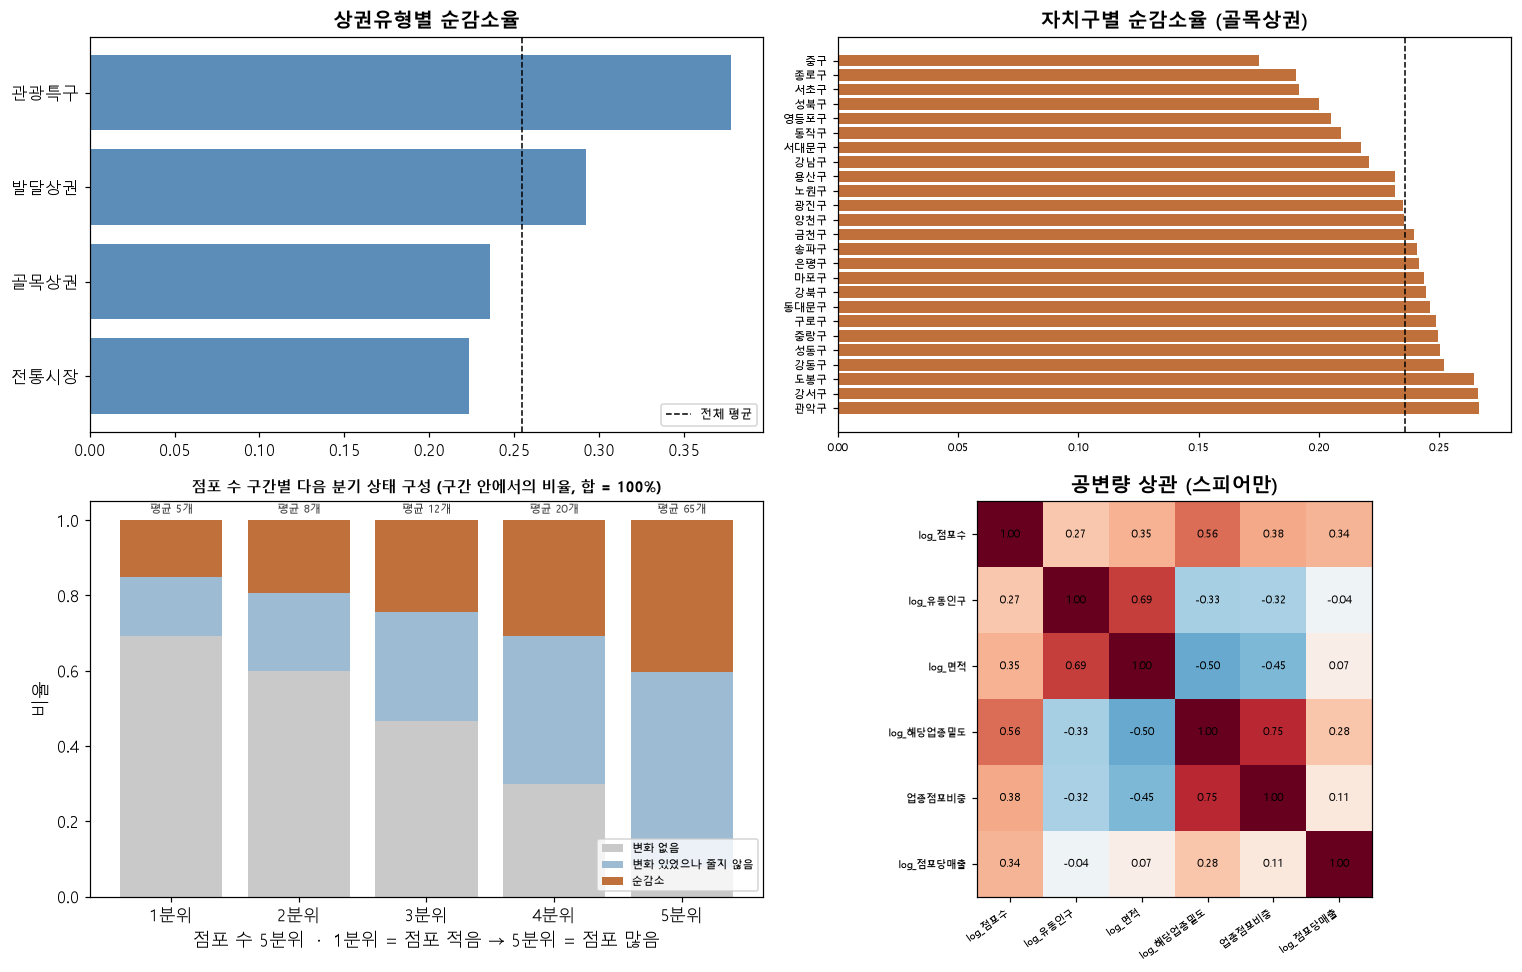

상관이 큰 쌍 (스피어만)
  log_해당업종밀도       ~ 업종점포비중           +0.753
  log_유동인구         ~ log_면적           +0.692
  log_점포수          ~ log_해당업종밀도       +0.558
  log_면적           ~ log_해당업종밀도       -0.503

|r| > 0.8 인 쌍 0개

※ 0.6이라는 눈금에 규칙은 없음. 그리고 트리 계열 모형에서 상관은 «예측»을 망치지 않음.
  망치는 것은 «해석»임 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져서
  각각의 중요도가 실제보다 낮게 보임. 다음 노트북에서 SHAP 순위를 읽을 때
  위 상위 쌍은 하나의 덩어리로 보아야 함.


In [21]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
ax[0,0].barh(t_type.index, t_type["순감소율"], color="#5b8db8")
ax[0,0].axvline(d["y"].mean(), ls="--", c="k", lw=1, label="전체 평균")
ax[0,0].set_title("상권유형별 순감소율", weight="bold"); ax[0,0].legend(fontsize=8)

ax[0,1].barh(t_gu.index, t_gu["순감소율"], color="#c0703a")
ax[0,1].axvline(gm["y"].mean(), ls="--", c="k", lw=1)
ax[0,1].set_title(f"자치구별 순감소율 ({TARGET_TYPE})", weight="bold"); ax[0,1].tick_params(labelsize=7)

st = d.groupby(["규모구간", "다음상태"], observed=True).size().unstack(fill_value=0)
st = st.div(st.sum(axis=1), axis=0)[[S_NONE, S_FLAT, S_DROP]]
bot = np.zeros(len(st))
for c, col in zip(st.columns, ["#c9c9c9", "#9dbcd4", "#c0703a"]):
    ax[1,0].bar([f"{i+1}분위" for i in st.index], st[c], bottom=bot, color=col, label=c)
    bot += st[c].values
ax[1,0].set_title("점포 수 구간별 다음 분기 상태 구성 (구간 안에서의 비율, 합 = 100%)",
                  weight="bold", fontsize=10)
ax[1,0].set_xlabel("점포 수 5분위  ·  1분위 = 점포 적음 → 5분위 = 점포 많음")
for xi, (qi, row) in enumerate(st.iterrows()):
    ax[1,0].text(xi, 1.02, f"평균 {size_tab['평균점포'].iloc[xi]:.0f}개",
                 ha="center", fontsize=7.5, color="#444")
ax[1,0].legend(fontsize=7, loc="lower right"); ax[1,0].set_ylabel("비율")

cov = ["log_점포수", "log_유동인구", "log_면적", "log_해당업종밀도", "업종점포비중",
       "log_점포당매출"]
corr = d[cov].corr(method="spearman")
im = ax[1,1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1,1].set_xticks(range(len(cov))); ax[1,1].set_xticklabels(cov, rotation=35, fontsize=6.5, ha="right")
ax[1,1].set_yticks(range(len(cov))); ax[1,1].set_yticklabels(cov, fontsize=6.5)
for i in range(len(cov)):
    for j in range(len(cov)):
        ax[1,1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax[1,1].set_title("공변량 상관 (스피어만)", weight="bold")
plt.tight_layout(); plt.savefig(FIG / "basic_eda.png", dpi=130); plt.show()
pairs = [(cov[a], cov[b], corr.iloc[a, b]) for a in range(len(cov)) for b in range(a+1, len(cov))]
pairs.sort(key=lambda t: -abs(t[2]))
print("상관이 큰 쌍 (스피어만)")
for a_, b_, v_ in pairs[:4]:
    print(f"  {a_:16} ~ {b_:16} {v_:+.3f}")
print(f"\n|r| > 0.8 인 쌍 {sum(1 for _,_,v_ in pairs if abs(v_) > 0.8)}개")
print("\n※ 0.6이라는 눈금에 규칙은 없음. 그리고 트리 계열 모형에서 상관은 «예측»을 망치지 않음.")
print("  망치는 것은 «해석»임 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져서")
print("  각각의 중요도가 실제보다 낮게 보임. 다음 노트북에서 SHAP 순위를 읽을 때")
print("  위 상위 쌍은 하나의 덩어리로 보아야 함.")

---
# 5. 기준선과 가설 검토

모델을 만들기 전에 **아무것도 안 하는 규칙이 얼마나 맞히는지** 먼저 재 둠.
이 값을 넘지 못하면 모델을 쓸 이유가 없음.

## 5-1. 기준선 네 가지

| 기준선 | 규칙 |
|---|---|
| 무작위 | 전체 양성률(기저율) |
| 직전 분기 | 직전 분기에 순감소였으면 위험으로 찍음 |
| 상권변화지표 | 서울시 공식 지표가 `HL 상권축소`이면 위험으로 찍음 |
| **점포 수** | 점포 수가 많은 칸부터 차례로 위험으로 찍음 |

**«점포 수» 를 반드시 넣어야 하는 이유** — 3-1에서 본 것처럼 큰 칸일수록 사건이 자주 일어나고
그만큼 순감소로 잡힐 확률도 높음. 즉 **점포 수 하나만 알아도 어느 정도는 맞힘.**
이 기준선을 세워 두지 않으면 모델의 성능이 «위험을 읽어낸 것» 인지
«그냥 큰 칸을 고른 것» 인지 구분할 수 없음.

공정한 비교를 위해 점포 수 기준선이 위험으로 찍는 개수를 **직전 분기 기준선과 같게** 맞춤.
`Lift = 정밀도 ÷ 기저율` 이며, 1.0이면 무작위와 같음. (Lift 1.5 = 아무렇게나 찍을 때보다 1.5배 잘 맞힘)


In [22]:
def evaluate(y_true, pred, name):
    y_true = np.asarray(y_true); pred = np.asarray(pred)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    base = y_true.mean()
    prec = tp / (tp + fp) if tp + fp else np.nan
    rec  = tp / (tp + fn) if tp + fn else np.nan
    return {"기준선": name, "위험으로 찍은 수": tp + fp, "정밀도": prec, "재현율": rec,
            "Lift": prec / base if base else np.nan}

b = d[d["상권_변화_지표"].notna()].copy()
k = int(b["순감소_현재"].sum())                      # 직전 분기 기준선이 찍은 개수와 같게 맞춤
규모예측 = np.zeros(len(b), dtype=int)
규모예측[np.argsort(-b["전체_점포_수"].values, kind="stable")[:k]] = 1
b["점포수만"] = 규모예측

rows = [evaluate(b["y"], np.ones(len(b)), "무작위(전부 위험)"),
        evaluate(b["y"], b["순감소_현재"], "직전 분기"),
        evaluate(b["y"], b["기준선_위험"], "상권변화지표(HL)"),
        evaluate(b["y"], b["점포수만"],    f"점포 수(상위 {k:,}칸)")]
bl = pd.DataFrame(rows)
bl[["정밀도", "재현율", "Lift"]] = bl[["정밀도", "재현율", "Lift"]].round(3)
display(bl)
base_ = b["y"].mean()
best_ = bl.loc[bl["Lift"].idxmax()]
print(f"기저율 {base_:.1%} = 무작위로 찍을 때의 기대 정밀도이며, 이 값이 Lift 1.0의 기준임.")
print(f"따라서 모델이 넘어야 하는 선은 기저율이 아니라 위 네 기준선 중 가장 높은 것임 —")
print(f"  «{best_['기준선']}»  정밀도 {best_['정밀도']:.3f} · Lift {best_['Lift']:.3f}")
print(f"이 값을 넘지 못하면, 그 규칙 하나로 대체할 수 있으므로 모델을 쓸 이유가 없음.")

,기준선,위험으로 찍은 수,정밀도,재현율,Lift
0,무작위(전부 위험),67475,0.255,1,1
1,직전 분기,15682,0.284,0.259,1.11
2,상권변화지표(HL),12608,0.244,0.179,0.956
3,"점포 수(상위 15,682칸)",15682,0.394,0.359,1.54


기저율 25.5% = 무작위로 찍을 때의 기대 정밀도이며, 이 값이 Lift 1.0의 기준임.
따라서 모델이 넘어야 하는 선은 기저율이 아니라 위 네 기준선 중 가장 높은 것임 —
  «점포 수(상위 15,682칸)»  정밀도 0.394 · Lift 1.545
이 값을 넘지 못하면, 그 규칙 하나로 대체할 수 있으므로 모델을 쓸 이유가 없음.


In [23]:
ct2 = pd.crosstab(b["순감소_현재"], b["y"])
chi2, p, dof, _ = chi2_contingency(ct2, correction=False)
V = np.sqrt(chi2 / ct2.values.sum())
OR = (ct2.iloc[1,1] * ct2.iloc[0,0]) / (ct2.iloc[1,0] * ct2.iloc[0,1])
display(ct2)
print(f"chi2({dof}) = {chi2:.1f}, p = {plain(p)}, Cramer V = {V:.3f}, 오즈비 = {OR:.2f}")
print("-> p는 사실상 0이지만 V가 작으면 직전 분기만으로는 예측력이 약하다는 뜻임. "
      "p-value만 보고 결론을 내면 안 되는 이유의 실물임.")

y,0,1
순감소_현재,,
0,39057,12736
1,11228,4454


chi2(1) = 92.1, p = 0, Cramer V = 0.037, 오즈비 = 1.22
-> p는 사실상 0이지만 V가 작으면 직전 분기만으로는 예측력이 약하다는 뜻임. p-value만 보고 결론을 내면 안 되는 이유의 실물임.


## 5-2. 점포 수를 고정하고 다시 재기

전체 표본에서 잰 값에는 «규모가 큰 칸을 골라낸 몫»이 섞여 있음.
그래서 **점포 수 5분위 안에서 같은 기준을 다시 잼.** 구간 안에서는 칸의 크기가 서로 비슷하므로,
여기서도 값이 1을 넘으면 그 기준은 **규모가 아닌 무언가**를 읽고 있다고 말할 수 있음.

### 교차 검증의 층화 추출과는 다른 것임

이름이 비슷해 혼동되기 쉬우므로 구분해 둠.

| | `StratifiedKFold` (층화 추출) | 여기서 하는 것 (구간별 재계산) |
|---|---|---|
| 무엇을 하는가 | **데이터를 나눔** — 학습·검증 폴드를 만듦 | 이미 나온 결과를 **구간별로 다시 잼** |
| 기준으로 삼는 변수 | **라벨** — 폴드마다 양성 비율을 같게 유지 | **점포 수** — 교란이 될 공변량 |
| 학습이 일어나는가 | 폴드마다 k번 학습 | **학습 없음.** `groupby` 후 지표만 재계산 |
| 무엇을 얻는가 | 교차검증 성능 추정치 | 구간별 성능 표 |

**이 노트북은 교차 검증을 쓰지 않음.** 시간 순서로 나누기 때문임 —
무작위로 섞어 폴드를 만들면 미래 분기가 학습에 새어 들어감.

여기서 하는 것은 **교란 통제**에 해당함. 점포 수가 라벨과 함께 움직이므로,
그 값을 비슷한 것끼리 묶어 놓고 비교해야 «크기 때문인가, 다른 이유인가»가 갈림.
뒤의 성향점수매칭이 같은 목적을 더 정교하게 하는 방법이고, 이 절은 그 앞단계의 거친 형태임.


In [24]:
rows = []
for q_, s in b.groupby("규모구간"):
    base = s["y"].mean()
    kk = int(s["순감소_현재"].sum())
    pred_size = np.zeros(len(s), dtype=int)
    pred_size[np.argsort(-s["전체_점포_수"].values, kind="stable")[:kk]] = 1
    r = {"규모구간": f"{int(q_)+1}분위", "칸수": len(s),
         "평균점포": round(s["전체_점포_수"].mean(), 1), "기저율": round(base, 3)}
    for nm, pred in [("직전 분기", s["순감소_현재"].values), ("상권변화지표", s["기준선_위험"].values),
                     ("점포 수", pred_size)]:
        tp = int(((pred == 1) & (s["y"].values == 1)).sum()); n1 = int(pred.sum())
        r[f"{nm} Lift"] = round((tp / n1) / base, 3) if n1 and base else np.nan
    rows.append(r)
strat = pd.DataFrame(rows).set_index("규모구간")
display(strat)
print("-> «점포 수» 의 층내 Lift가 1 근처로 내려가면, 전체 표본에서의 성능이")
print("   상권의 위험을 읽은 것이 아니라 규모를 고른 결과였다는 뜻임.")

,칸수,평균점포,기저율,직전 분기 Lift,상권변화지표 Lift,점포 수 Lift
규모구간,,,,,,
1분위,15520,5.4,0.151,0.947,1.01,1.13
2분위,14018,7.9,0.193,0.963,1.05,1.15
3분위,12139,11.7,0.243,1,1.01,1.09
4분위,12718,19.6,0.308,0.955,1.06,1.1
5분위,13080,65.5,0.403,1.01,0.969,1.06


-> «점포 수» 의 층내 Lift가 1 근처로 내려가면, 전체 표본에서의 성능이
   상권의 위험을 읽은 것이 아니라 규모를 고른 결과였다는 뜻임.


### 구간별 표를 정식 검정으로 — Cochran-Mantel-Haenszel

구간별 값을 나열하는 것만으로는 **서술**에 머묾. 「점포 수를 통제한 뒤에도 연관이 있는가」를
하나의 검정 통계량으로 답해야 통계적 주장이 됨. 그 표준 방법이 **Cochran-Mantel-Haenszel(CMH)** 검정임.

| 구성 요소 | 내용 |
|---|---|
| 층(stratum) | 점포 수 5분위 — 교란이 되는 규모를 층으로 묶음 |
| 층마다 만드는 표 | `상권유형(골목상권 여부) × y(다음 분기 순감소)` 2×2 |
| CMH 검정 | 층을 통제한 상태에서 두 변수의 연관이 있는지 검정 (자유도 1) |
| Mantel-Haenszel 공통 오즈비 | 층별 오즈비를 표본 크기로 가중해 하나로 합친 값 |
| Woolf 동질성 검정 | 층별 오즈비가 서로 같다고 볼 수 있는지 — 다르면 공통 오즈비를 하나로 말할 수 없음 |

**5분위를 쓰는 근거가 있음.** 성향점수를 다섯 층으로 나누면 교란 편향의 대부분이 제거된다는 것이
층화 분석의 표준 관행이며, 층 수를 늘려도 얻는 것이 빠르게 줄어듦.
여기서는 성향점수 대신 **주요 교란 변수인 점포 수 자체**로 층을 나눔.
성향점수를 쓰는 정교한 형태는 5-7 에서 다룸.

**읽는 순서** — ① Woolf 동질성이 성립하는지 먼저 보고, ② 성립하면 공통 오즈비와 CMH p-value 를 읽음.
동질성이 깨지면 층을 합쳐 하나의 값으로 말할 수 없으므로 층별 오즈비를 그대로 보고해야 함.


In [25]:
from scipy.stats import chi2

def cmh_test(df, exposure, outcome, stratum):
    """Cochran-Mantel-Haenszel — 층을 통제한 2x2 연관 검정
    반환: 층별 표, CMH 통계량·p, MH 공통 오즈비·95% CI, Woolf 동질성"""
    rows, A, EA, VA, num, den, logors, ws = [], 0.0, 0.0, 0.0, 0.0, 0.0, [], []
    for k, s in df.groupby(stratum, observed=True):
        a = int(((s[exposure] == 1) & (s[outcome] == 1)).sum())   # 노출·사건
        b = int(((s[exposure] == 1) & (s[outcome] == 0)).sum())   # 노출·비사건
        c = int(((s[exposure] == 0) & (s[outcome] == 1)).sum())
        e = int(((s[exposure] == 0) & (s[outcome] == 0)).sum())
        n = a + b + c + e
        if min(a + b, c + e, a + c, b + e) == 0 or n == 0:
            continue
        A += a
        EA += (a + b) * (a + c) / n
        VA += (a + b) * (c + e) * (a + c) * (b + e) / (n ** 2 * (n - 1))
        num += a * e / n
        den += b * c / n
        or_k = (a * e) / (b * c) if b * c else np.nan
        if np.isfinite(or_k) and or_k > 0 and min(a, b, c, e) > 0:
            v = 1/a + 1/b + 1/c + 1/e
            logors.append(np.log(or_k)); ws.append(1 / v)
        rows.append({"층": k, "노출·사건": a, "노출·비사건": b,
                     "비노출·사건": c, "비노출·비사건": e,
                     "노출군 사건률": a / (a + b), "비노출군 사건률": c / (c + e),
                     "층 오즈비": or_k})
    tab = pd.DataFrame(rows).set_index("층")
    cmh = (abs(A - EA) - 0.5) ** 2 / VA if VA > 0 else np.nan
    p_cmh = 1 - chi2.cdf(cmh, 1)
    or_mh = num / den if den else np.nan
    # 공통 오즈비 신뢰구간 — 로그 척도에서 Woolf 가중 분산 사용
    if ws:
        se = np.sqrt(1 / np.sum(ws))
        lo, hi = np.exp(np.log(or_mh) - 1.96 * se), np.exp(np.log(or_mh) + 1.96 * se)
        lw = np.sum(ws)
        q = float(np.sum(np.array(ws) * (np.array(logors) - np.log(or_mh)) ** 2))
        p_hom = 1 - chi2.cdf(q, max(len(ws) - 1, 1))
    else:
        lo = hi = q = p_hom = np.nan
    return tab, dict(CMH=cmh, p_CMH=p_cmh, OR_MH=or_mh, CI=(lo, hi),
                     Woolf_Q=q, p_homogeneity=p_hom, n층=len(rows))

# 보조 질문 — «골목상권이 다른 유형보다 위험한가»를 점포 수를 통제하고 검정함
b2 = d.copy()
b2["골목상권"] = (b2["상권유형"] == TARGET_TYPE).astype(int)
tab, res = cmh_test(b2, "골목상권", "y", "규모구간")
disp = tab.copy()
disp.index = [f"{int(i)+1}분위" for i in disp.index]
display(disp.round(4))

print("층을 통제하지 않은 단순 비교")
p1_ = b2.loc[b2["골목상권"] == 1, "y"].mean(); p0_ = b2.loc[b2["골목상권"] == 0, "y"].mean()
or_raw = (p1_ / (1 - p1_)) / (p0_ / (1 - p0_))
print(f"  골목상권 {p1_:.4f} · 그 밖 {p0_:.4f} · 오즈비 {or_raw:.3f}")
print()
print(f"Woolf 동질성 검정   Q = {res['Woolf_Q']:.3f}, p = {plain(res['p_homogeneity'])}"
      f"  → 층별 오즈비가 {'서로 다름 (합쳐 말할 수 없음)' if res['p_homogeneity'] < .05 else '서로 같다고 볼 수 있음'}")
print(f"MH 공통 오즈비      {res['OR_MH']:.3f}  95% CI [{res['CI'][0]:.3f}, {res['CI'][1]:.3f}]"
      f"  → 1을 {'포함하지 않음' if not (res['CI'][0] < 1 < res['CI'][1]) else '포함함'}")
print(f"CMH 검정            chi2(1) = {res['CMH']:.3f}, p = {plain(res['p_CMH'])}"
      f"  → {'유의' if res['p_CMH'] < .05 else '비유의'}  (층 {res['n층']}개)")
print()
print("단순 오즈비와 공통 오즈비를 견주면 점포 수가 만든 교란의 크기가 보임.")
print("두 값이 크게 다르면 단순 비교가 규모 차이를 읽고 있었다는 뜻임.")

,노출·사건,노출·비사건,비노출·사건,비노출·비사건,노출군 사건률,비노출군 사건률,층 오즈비
1분위,1618,8636,728,4538,0.1578,0.1382,1.17
2분위,1701,6817,1009,4491,0.1997,0.1835,1.11
3분위,1665,4934,1281,4259,0.2523,0.2312,1.12
4분위,1805,3862,2118,4933,0.3185,0.3004,1.09
5분위,1377,2232,3888,5583,0.3815,0.4105,0.8859


층을 통제하지 않은 단순 비교
  골목상권 0.2357 · 그 밖 0.2749 · 오즈비 0.813

Woolf 동질성 검정   Q = 27.387, p = 0.000016601529271  → 층별 오즈비가 서로 다름 (합쳐 말할 수 없음)
MH 공통 오즈비      1.061  95% CI [1.023, 1.101]  → 1을 포함하지 않음
CMH 검정            chi2(1) = 9.834, p = 0.0017  → 유의  (층 5개)

단순 오즈비와 공통 오즈비를 견주면 점포 수가 만든 교란의 크기가 보임.
두 값이 크게 다르면 단순 비교가 규모 차이를 읽고 있었다는 뜻임.


## 5-3. 업종별 순감소율과 규모 교란

처리군은 **선험적 근거로 미리 고정함.** 순감소율이 가장 높은 업종을 고른 다음 그 격차를 검정하면
선택 효과가 섞여 들어가기 때문임. 표본이 가장 크고 골목상권을 대표하는 **한식음식점**으로 정함.

In [26]:
gm = d[d["상권유형"] == TARGET_TYPE].copy()
t_ind = (gm.groupby("서비스_업종_코드_명")
         .agg(순감소율=("y", "mean"), 칸수=("y", "size"),
              평균점포=("전체_점포_수", "mean"), 중앙유동인구=("총_유동인구_수", "median"))
         .sort_values("순감소율", ascending=False))
display(t_ind.round(3))

TREAT = "한식음식점"          # 선험적 고정 (표본 최대 · 대표 업종)
gm["처리"] = (gm["서비스_업종_코드_명"] == TREAT).astype(int)
p1 = gm.loc[gm["처리"] == 1, "y"].mean(); p0 = gm.loc[gm["처리"] == 0, "y"].mean()
print(f"\n처리군 {TREAT} n={int(gm['처리'].sum()):,} 순감소율 {p1:.1%}")
print(f"대조군 기타 외식  n={int((1-gm['처리']).sum()):,} 순감소율 {p0:.1%}")
print(f"단순 격차 {p1-p0:+.1%}p")

,순감소율,칸수,평균점포,중앙유동인구
서비스_업종_코드_명,,,,
한식음식점,0.253,9957,21.32,"779,241"
커피-음료,0.244,7741,12.6,"893,978"
호프-간이주점,0.239,4596,11.78,"1,170,658"
패스트푸드점,0.237,1440,7.09,"1,515,928.5"
양식음식점,0.228,1478,11.12,"1,305,611.5"
분식전문점,0.222,3634,8.23,"1,264,523"
일식음식점,0.216,1036,8.42,"1,549,588.5"
제과점,0.206,1636,7.41,"1,319,055.5"
치킨전문점,0.201,1922,6.7,"1,391,462.5"



처리군 한식음식점 n=9,957 순감소율 25.3%
대조군 기타 외식  n=24,690 순감소율 22.9%
단순 격차 +2.4%p


In [27]:
r = np.corrcoef(t_ind["평균점포"], t_ind["순감소율"])[0, 1]
print(f"업종 평균점포수 <-> 순감소율 상관 r = {r:.3f}")
print("r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 큼\n")

piv = gm.pivot_table(index="규모구간", columns="처리", values="y",
                     aggfunc=["mean", "size"], observed=True)
tbl = pd.DataFrame({"대조군_순감소율": piv[("mean", 0)], "처리군_순감소율": piv[("mean", 1)],
                    "대조n": piv[("size", 0)].astype("Int64"), "처리n": piv[("size", 1)].astype("Int64")})
tbl["격차"] = tbl["처리군_순감소율"] - tbl["대조군_순감소율"]
tbl.index = [f"{int(i)+1}분위" for i in tbl.index]
display(tbl.round(3))
print("※ 규모 구간을 고정했을 때 격차가 줄거나 부호가 뒤집히면, 단순 격차는 규모 교란의 산물임")

업종 평균점포수 <-> 순감소율 상관 r = 0.657
r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 큼



,대조군_순감소율,처리군_순감소율,대조n,처리n,격차
1분위,0.163,0.118,9147,1107,-0.044
2분위,0.211,0.15,6914,1604,-0.061
3분위,0.269,0.208,4766,1833,-0.061
4분위,0.343,0.294,2827,2840,-0.048
5분위,0.435,0.36,1036,2573,-0.075


※ 규모 구간을 고정했을 때 격차가 줄거나 부호가 뒤집히면, 단순 격차는 규모 교란의 산물임


### 처리군을 미리 고정해야 하는 이유 — 순열검정으로 확인

「순감소율이 가장 높은 업종을 고른 뒤 그 격차를 검정한다」가 왜 안 되는지를 수치로 보임.

**업종 사이에 진짜 차이가 0이라고 가정**하고 `y`를 무작위로 섞어 같은 계산을 2,000번 반복함.
차이가 없는데도 «10개 중 최고»는 전체 평균보다 높게 나옴 — 10번 뽑아 최대를 고르는 행위 자체가
**위쪽 꼬리를 뽑기** 때문임. 표집 오차의 운이 좋았던 업종이 1위가 됨.

그래서 최고를 고른 뒤 그 격차를 검정하면 **이미 부풀려진 값을 검정**하는 것이고,
p-value가 실제보다 작게(더 유의하게) 나옴. 같은 데이터로 «고르기»와 «검정»을 둘 다 해서 생기는 문제임.


In [28]:
rng = np.random.default_rng(0)
ind = gm["서비스_업종_코드_명"].values; yv = gm["y"].values
obs = gm.groupby("서비스_업종_코드_명")["y"].mean()
gap_obs = obs.max() - obs.min()

gaps, maxs = [], []
for _ in range(2000):
    m_ = pd.Series(rng.permutation(yv)).groupby(ind).mean()
    gaps.append(m_.max() - m_.min()); maxs.append(m_.max())
gaps = np.array(gaps); maxs = np.array(maxs)

print(f"관측  최고({obs.idxmax()}) {obs.max():.3f} − 최저({obs.idxmin()}) {obs.min():.3f} = 격차 {gap_obs:.4f}")
print(f"\n업종 간 차이가 0이라고 가정하고 2,000번 섞으면")
print(f"  최고−최저 격차     평균 {gaps.mean():.4f} · 95분위 {np.quantile(gaps,.95):.4f} · 최대 {gaps.max():.4f}")
print(f"  «최고» 업종 순감소율 평균 {maxs.mean():.4f}  (전체 평균 {yv.mean():.4f})")
print(f"  → 아무 차이가 없어도 «최고»는 전체 평균보다 {maxs.mean()-yv.mean():+.4f} 높게 나옴")
print(f"     이 {maxs.mean()-yv.mean():+.4f} 가 «선택 효과»의 크기임\n")
p_perm = (gaps >= gap_obs).mean()
print(f"순열 p-value = {plain(p_perm)}  →  " +
      ("업종 간 차이는 우연으로 설명되지 않음" if p_perm < .05 else "우연 범위 안"))
print("단, 이것은 «차이가 있는가»에 대한 사후 확인임.")
print("처리군을 무엇으로 할지는 이 결과를 보기 전에 정해야 하므로 한식음식점을 선험적으로 고정함.")

관측  최고(한식음식점) 0.253 − 최저(중식음식점) 0.191 = 격차 0.0613

업종 간 차이가 0이라고 가정하고 2,000번 섞으면
  최고−최저 격차     평균 0.0297 · 95분위 0.0456 · 최대 0.0658
  «최고» 업종 순감소율 평균 0.2506  (전체 평균 0.2357)
  → 아무 차이가 없어도 «최고»는 전체 평균보다 +0.0149 높게 나옴
     이 +0.0149 가 «선택 효과»의 크기임

순열 p-value = 0.001  →  업종 간 차이는 우연으로 설명되지 않음
단, 이것은 «차이가 있는가»에 대한 사후 확인임.
처리군을 무엇으로 할지는 이 결과를 보기 전에 정해야 하므로 한식음식점을 선험적으로 고정함.


## 5-4. 공변량 균형 (SMD)

|SMD| < 0.1 균형 / 0.1~0.25 불균형 / 0.25 초과 심각.
두 집단을 비교하려면 **비교 전에 조건이 맞아 있는지** 부터 확인해야 함.

In [29]:
COVARIATES = ["log_점포수", "log_유동인구", "log_면적", "log_해당업종밀도",
              "log_점포당매출", "업종점포비중"]
def smd(a, b_):
    return (a.mean() - b_.mean()) / np.sqrt((a.var() + b_.var()) / 2)

rows = []
for c in COVARIATES:
    a = gm.loc[gm["처리"] == 1, c].dropna(); b_ = gm.loc[gm["처리"] == 0, c].dropna()
    s = smd(a, b_)
    rows.append({"공변량": c, "처리군평균": a.mean(), "대조군평균": b_.mean(), "SMD": s,
                 "판정": "균형" if abs(s) < .1 else ("불균형" if abs(s) < .25 else "심각한 불균형")})
smd_tbl = pd.DataFrame(rows)
smd_tbl[["처리군평균", "대조군평균", "SMD"]] = smd_tbl[["처리군평균", "대조군평균", "SMD"]].round(3)
display(smd_tbl)

,공변량,처리군평균,대조군평균,SMD,판정
0,log_점포수,2.79,2.16,0.999,심각한 불균형
1,log_유동인구,13.41,13.82,-0.447,심각한 불균형
2,log_면적,11.35,11.65,-0.473,심각한 불균형
3,log_해당업종밀도,1.12,0.619,1.3,심각한 불균형
4,log_점포당매출,17.46,16.27,1.13,심각한 불균형
5,업종점포비중,0.113,0.043,1.56,심각한 불균형


## 5-5. 검정 방법 선택 — 정규성·등분산성

그룹 간 차이를 무엇으로 검정할지는 **분포가 정함.** 정규성·등분산성이 성립하면 ANOVA,
아니면 비모수 검정(Kruskal-Wallis)을 씀. 순서를 거꾸로 하면 안 되므로 먼저 확인함.

### 무엇에 대해 정규성을 볼 것인가

**라벨 `y`는 0/1 이진값이므로 그 자체에 Shapiro-Wilk를 걸면 의미가 없음.**
이진 변수는 정의상 정규분포가 아니고, 표본만 크면 p는 반드시 0으로 나옴 — 검정을 한 것이 아니라
«이진값은 정규분포가 아니다»라는 자명한 사실을 확인한 것에 불과함.

그래서 검정 단위를 **연속량**으로 올림. `상권 × 업종` 칸마다 12분기의 순감소 비율을 계산하면
0~1 사이의 연속값이 되고, 이것이 그룹 간에 비교할 «위험 수준»의 자연스러운 단위임.

```
분석 단위   상권 × 업종  (칸마다 12분기 관측)
검정 대상   그 칸의 순감소 비율 = 순감소 분기 수 ÷ 관측 분기 수
```

- **Shapiro-Wilk** — 각 그룹이 정규분포인가. 표본이 5,000을 넘으면 과민해지므로 그룹별 5,000개로 잘라 봄
- **Levene** — 그룹 간 분산이 같은가. 평균 대신 **중앙값 기준**(Brown-Forsythe)으로 함 —
  분포가 치우쳐 있을 때 평균 기준 Levene은 그 자체로 왜곡됨


In [30]:
from scipy.stats import shapiro, levene, kruskal, rankdata, norm, binomtest, probplot

# 칸 단위 순감소 비율 — 라벨(0/1)로는 정규성 논의가 성립하지 않으므로 연속량으로 올림
cell = (d.groupby(["상권_코드", "서비스_업종_코드_명", "상권유형", "자치구"], observed=True)
        .agg(순감소비율=("y", "mean"), 관측분기=("y", "size"),
             평균점포=("전체_점포_수", "mean")).reset_index())
n_all = d.groupby(["상권_코드", "서비스_업종_코드_명"]).ngroups
cell = cell[cell["관측분기"] >= 6]          # 관측이 적은 칸은 비율이 불안정하므로 제외
print(f"칸 단위 표본 {len(cell):,}개 (관측 6분기 이상) · 제외 {n_all - len(cell):,}개")
print(f"순감소비율  평균 {cell['순감소비율'].mean():.3f} · 중앙값 {cell['순감소비율'].median():.3f}")

def dist_check(by, max_n=5000):
    gs = [g["순감소비율"].dropna().values for _, g in cell.groupby(by, observed=True)]
    gs = [g for g in gs if len(g) >= 20]
    rng_ = np.random.default_rng(0)
    bad, ok_names = 0, []
    for (nm, _), g in zip(cell.groupby(by, observed=True), gs):
        gg = rng_.choice(g, max_n, replace=False) if len(g) > max_n else g
        if shapiro(gg).pvalue < 0.05: bad += 1
        else: ok_names.append(str(nm))
    lev = levene(*gs, center="median")
    return {"구분": by, "그룹 수": len(gs), "정규성 위배": f"{bad}/{len(gs)}",
            "정규성 성립 그룹": ", ".join(ok_names) if ok_names else "없음",
            "Levene 통계량": round(lev.statistic, 3), "Levene p": plain(lev.pvalue),
            "등분산성": "위배" if lev.pvalue < .05 else "성립"}

chk = pd.DataFrame([dist_check(b) for b in ["상권유형", "서비스_업종_코드_명", "자치구"]]).set_index("구분")
display(chk)
print("→ 정규성이 성립하지 않는 그룹이 많으면 주 검정은 Kruskal-Wallis 로 감. ANOVA 는 참고로만 둠.")

칸 단위 표본 5,687개 (관측 6분기 이상) · 제외 735개
순감소비율  평균 0.249 · 중앙값 0.250


,그룹 수,정규성 위배,정규성 성립 그룹,Levene 통계량,Levene p,등분산성
구분,,,,,,
상권유형,4,4/4,없음,16,0.000000000234641,위배
서비스_업종_코드_명,10,10/10,없음,10.83,0,위배
자치구,25,25/25,없음,1.45,0.0727,성립


→ 정규성이 성립하지 않는 그룹이 많으면 주 검정은 Kruskal-Wallis 로 감. ANOVA 는 참고로만 둠.


### 시각적 확인 — 검정만으로 끝내지 않음

Shapiro-Wilk 는 «정규분포가 아니다»만 말하고 **어떻게 아닌지**는 말하지 않음.
꼬리가 긴 것인지, 여러 봉우리인지, 바닥에 몰려 있는 것인지에 따라 대응이 달라지므로
그룹마다 패널을 따로 둔 Q-Q plot 과 Boxplot 을 함께 봄.

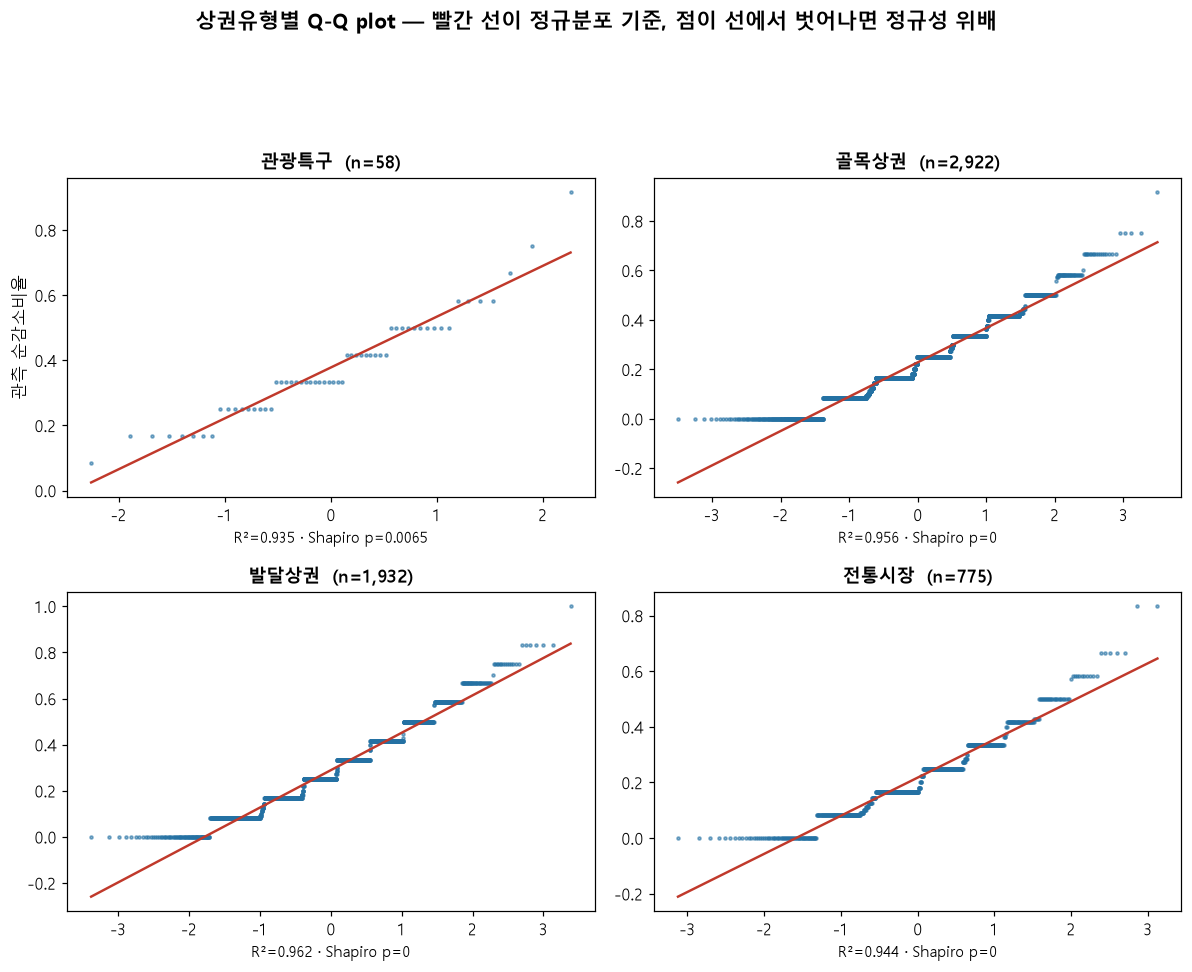

→ 오른쪽 끝이 빨간 선 위로 휘면 오른쪽 꼬리가 긴 분포임.
  왼쪽 끝이 수평으로 눌린 계단은 «12분기 중 순감소 0회» 칸이 한 값에 쌓인 자리임.


In [31]:
types = [t for t in cell["상권유형"].dropna().unique()
         if (cell["상권유형"] == t).sum() >= 20]
fig, ax = plt.subplots(2, 2, figsize=(11, 9))
ax = np.atleast_1d(ax).ravel()
for a_, t_ in zip(ax, types):
    v = cell.loc[cell["상권유형"] == t_, "순감소비율"].dropna().values
    (osm, osr), (sl, ic, r) = probplot(v, dist="norm")
    a_.plot(osm, osr, ".", ms=4, c="#2471a3", alpha=.55)
    a_.plot(osm, sl * osm + ic, "-", c="#c0392b", lw=1.6)
    pv = shapiro(v if len(v) <= 5000 else
                 np.random.default_rng(0).choice(v, 5000, replace=False)).pvalue
    a_.set_title(f"{t_}  (n={len(v):,})", fontsize=12, weight="bold")
    a_.set_xlabel(f"R²={r**2:.3f} · Shapiro p={plain(pv)}", fontsize=10)
    a_.set_ylabel("관측 순감소비율" if a_ is ax[0] else "", fontsize=11)
fig.suptitle("상권유형별 Q-Q plot — 빨간 선이 정규분포 기준, 점이 선에서 벗어나면 정규성 위배",
             fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, .90])
plt.savefig(FIG / "normality_qq_type.png", dpi=140); plt.show()
print("→ 오른쪽 끝이 빨간 선 위로 휘면 오른쪽 꼬리가 긴 분포임.")
print("  왼쪽 끝이 수평으로 눌린 계단은 «12분기 중 순감소 0회» 칸이 한 값에 쌓인 자리임.")

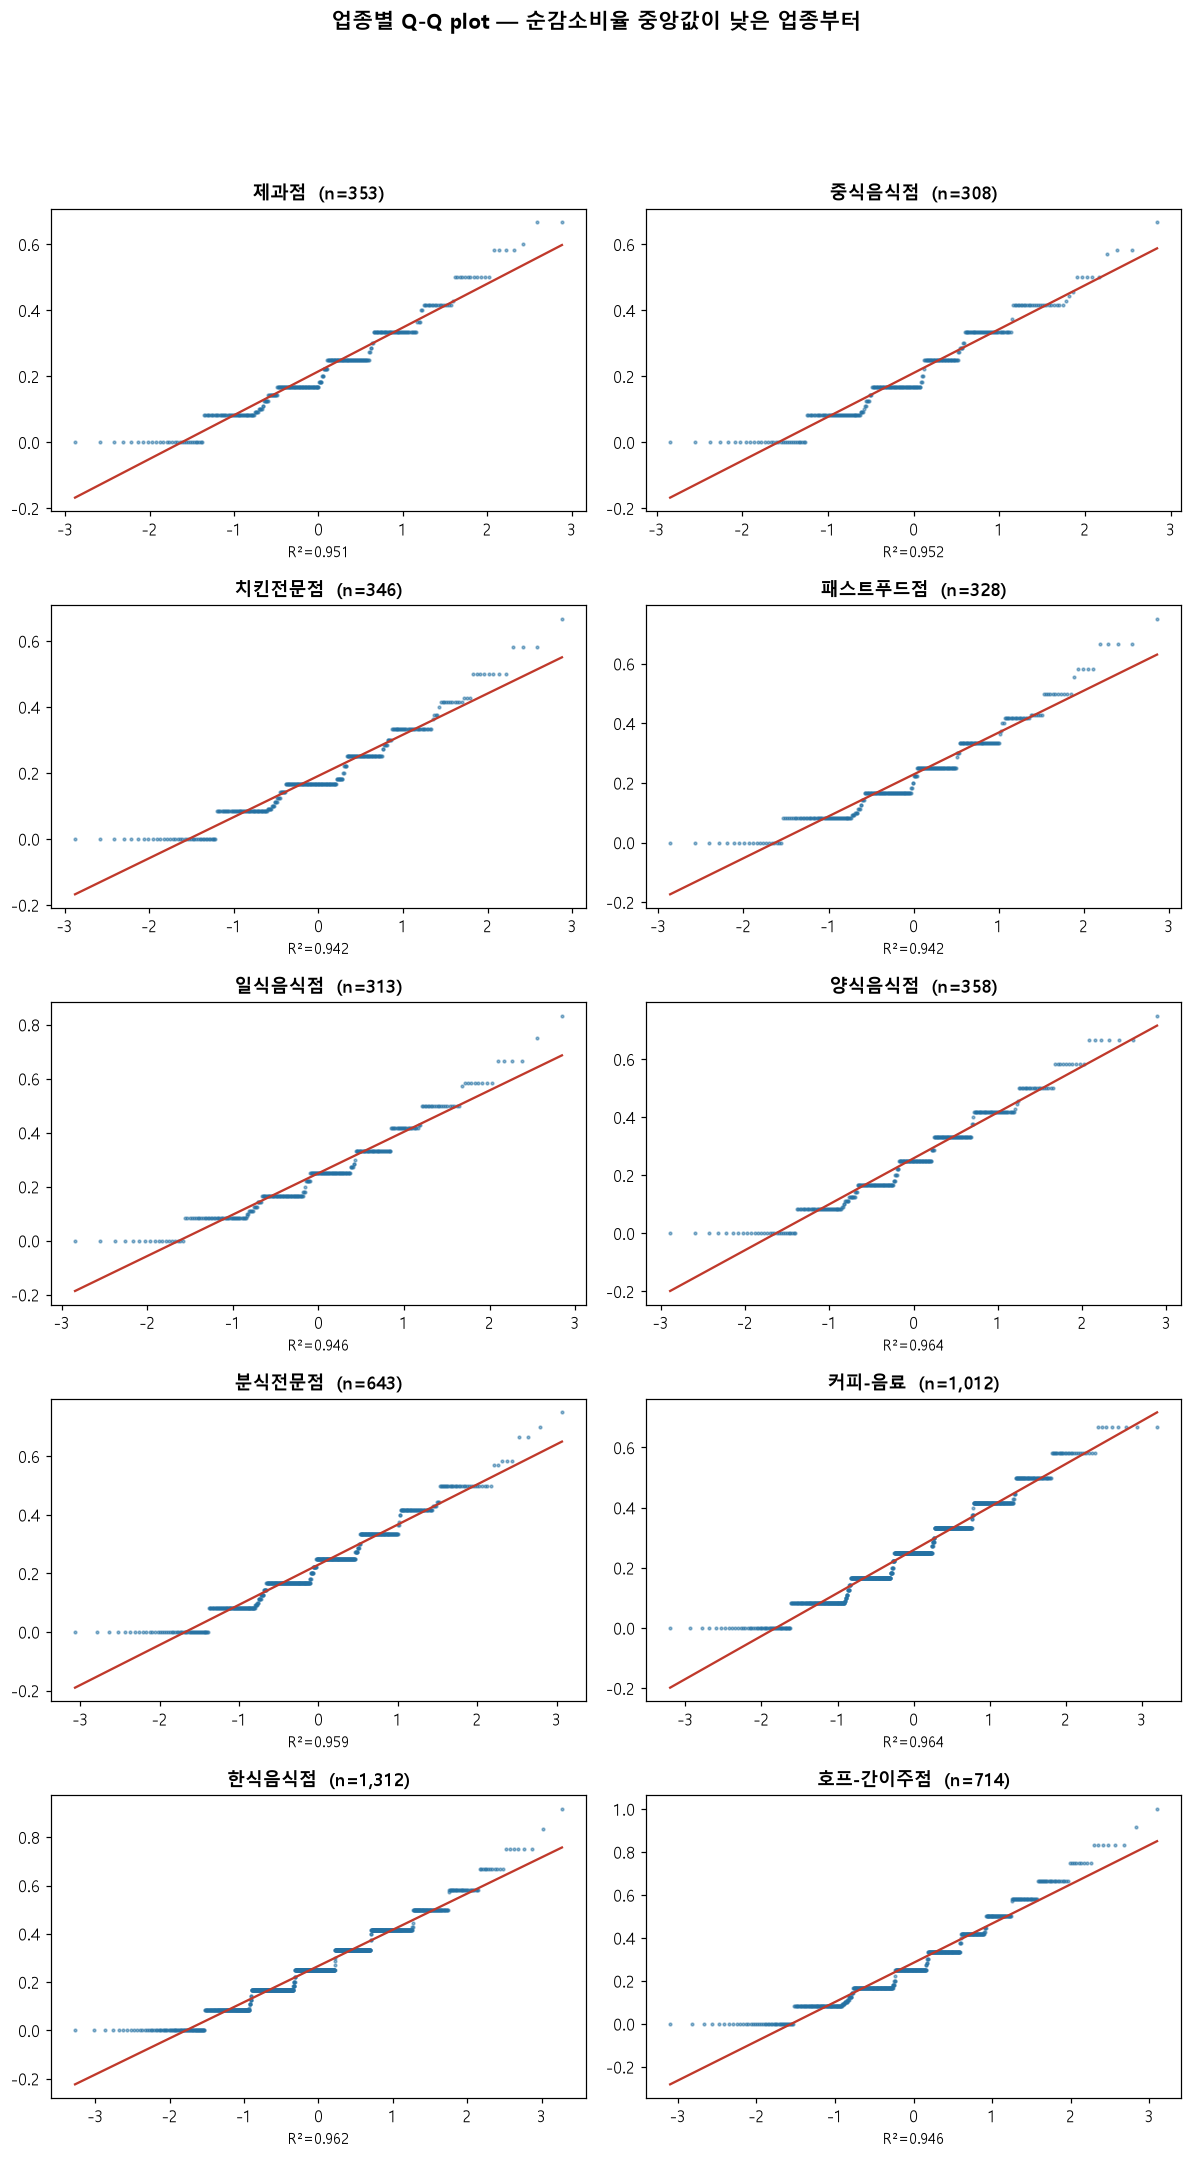

In [32]:
inds = list(cell.groupby("서비스_업종_코드_명")["순감소비율"].median().sort_values().index)
fig, ax = plt.subplots(5, 2, figsize=(11, 20))
ax = ax.ravel()
for a_, t_ in zip(ax, inds):
    v = cell.loc[cell["서비스_업종_코드_명"] == t_, "순감소비율"].dropna().values
    (osm, osr), (sl, ic, r) = probplot(v, dist="norm")
    a_.plot(osm, osr, ".", ms=3.5, c="#2471a3", alpha=.5)
    a_.plot(osm, sl * osm + ic, "-", c="#c0392b", lw=1.5)
    a_.set_title(f"{t_}  (n={len(v):,})", fontsize=11.5, weight="bold")
    a_.set_xlabel(f"R²={r**2:.3f}", fontsize=10)
for a_ in ax[len(inds):]: a_.axis("off")
fig.suptitle("업종별 Q-Q plot — 순감소비율 중앙값이 낮은 업종부터", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, .93])
plt.savefig(FIG / "normality_qq_industry.png", dpi=140); plt.show()

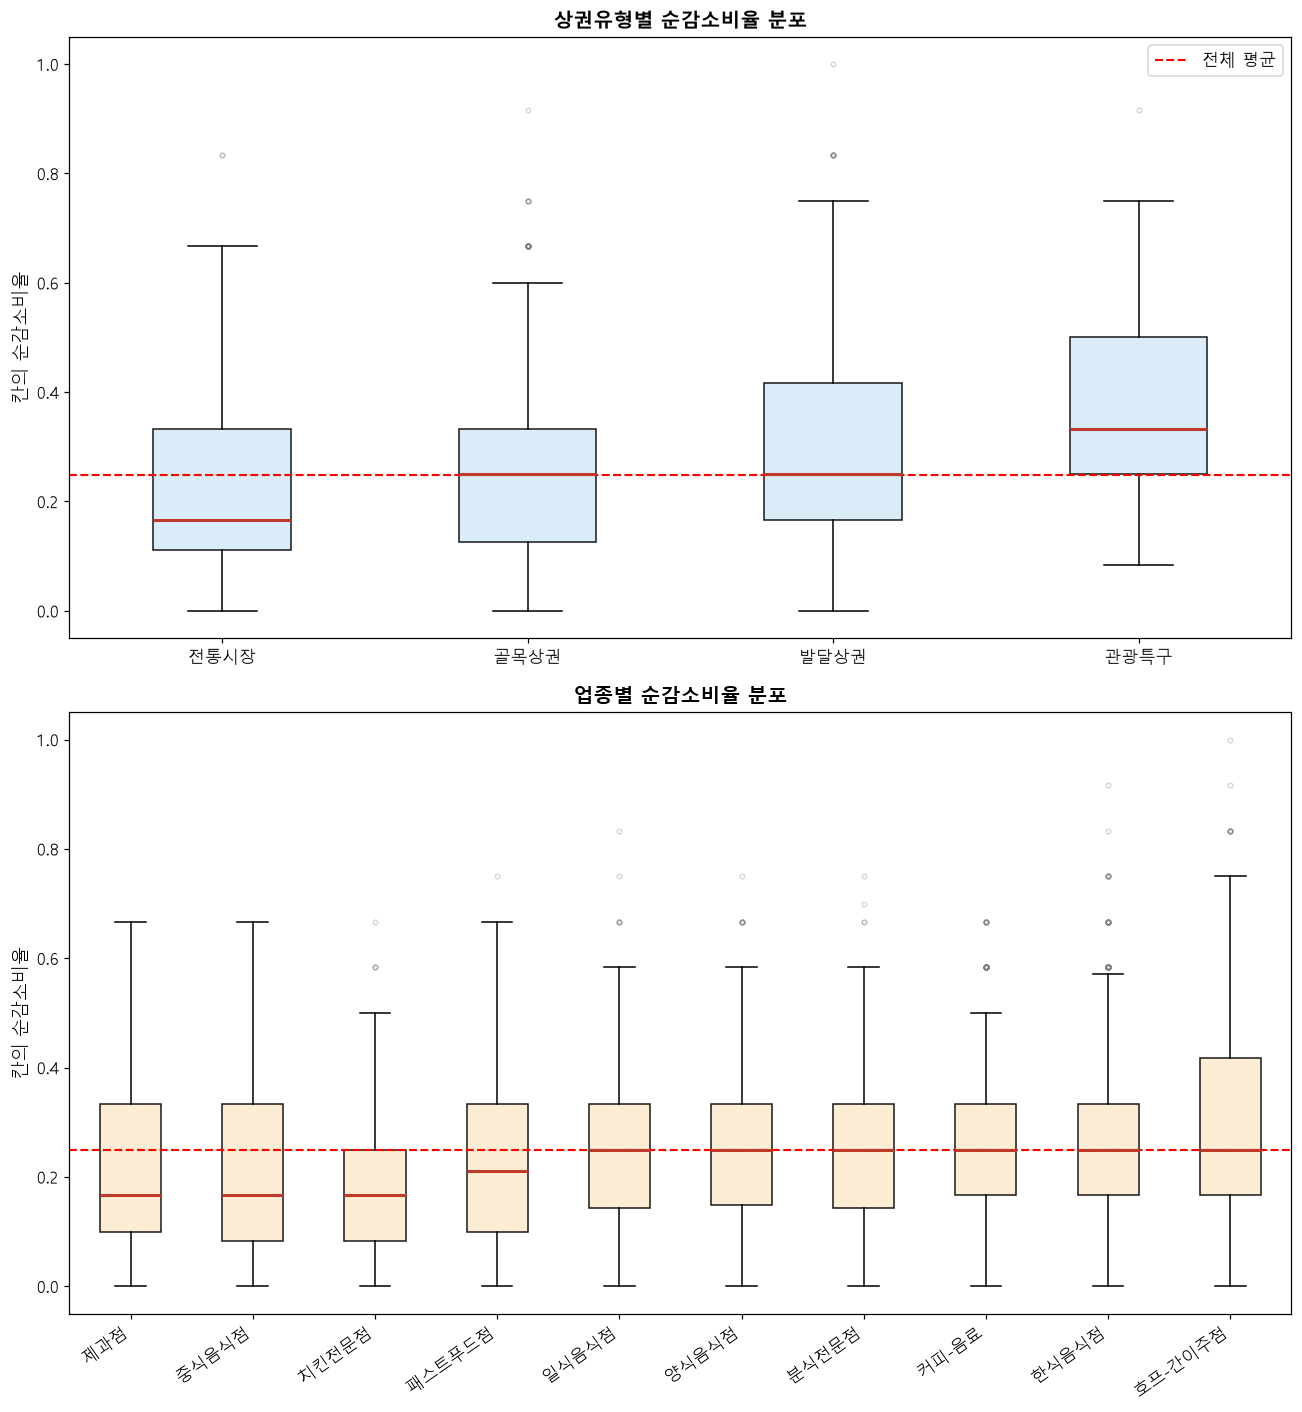

전체 분포  왜도 0.5917 · 첨도 0.2881 · 순감소가 한 번도 없던 칸 7.1%
→ 왜도가 양수이고 0에 몰린 칸이 있으면 오른쪽 꼬리가 긴 분포임.
  Boxplot 에서 상자 높이가 그룹마다 다른 것이 등분산성 위배의 모습임.
  이 형태에서는 평균 비교(ANOVA)가 중앙값 비교(Kruskal-Wallis)보다 불리함.


In [33]:
fig, ax = plt.subplots(2, 1, figsize=(12, 13))
order_t = cell.groupby("상권유형")["순감소비율"].median().sort_values().index.tolist()
bp1 = ax[0].boxplot([cell.loc[cell["상권유형"] == t_, "순감소비율"].values for t_ in order_t],
                    tick_labels=order_t, showfliers=True, patch_artist=True,
                    flierprops=dict(ms=3, alpha=.3, mec="gray"),
                    medianprops=dict(c="#c0392b", lw=2))
for b_ in bp1["boxes"]: b_.set(facecolor="#d6eaf8", alpha=.9)
ax[0].axhline(cell["순감소비율"].mean(), ls="--", c="r", lw=1.4, label="전체 평균")
ax[0].set_title("상권유형별 순감소비율 분포", weight="bold")
ax[0].set_ylabel("칸의 순감소비율"); ax[0].legend()

bp2 = ax[1].boxplot([cell.loc[cell["서비스_업종_코드_명"] == t_, "순감소비율"].values for t_ in inds],
                    tick_labels=inds, showfliers=True, patch_artist=True,
                    flierprops=dict(ms=3, alpha=.3, mec="gray"),
                    medianprops=dict(c="#c0392b", lw=2))
for b_ in bp2["boxes"]: b_.set(facecolor="#fdebd0", alpha=.9)
ax[1].axhline(cell["순감소비율"].mean(), ls="--", c="r", lw=1.4)
ax[1].set_title("업종별 순감소비율 분포", weight="bold")
ax[1].set_ylabel("칸의 순감소비율")
plt.setp(ax[1].get_xticklabels(), rotation=35, ha="right")
plt.tight_layout(); plt.savefig(FIG / "normality_box.png", dpi=140); plt.show()

sk = cell["순감소비율"].skew(); ku = cell["순감소비율"].kurtosis()
zero = (cell["순감소비율"] == 0).mean()
print(f"전체 분포  왜도 {plain(sk)} · 첨도 {plain(ku)} · 순감소가 한 번도 없던 칸 {zero:.1%}")
print("→ 왜도가 양수이고 0에 몰린 칸이 있으면 오른쪽 꼬리가 긴 분포임.")
print("  Boxplot 에서 상자 높이가 그룹마다 다른 것이 등분산성 위배의 모습임.")
print("  이 형태에서는 평균 비교(ANOVA)가 중앙값 비교(Kruskal-Wallis)보다 불리함.")

## 5-6. 가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구

보조 질문은 «상권유형에 따라 위험이 다른가»임. 그런데 전체를 한 번에 검정하면 **업종 구성이
섞여 들어감** — 특정 유형에 특정 업종이 몰려 있으면 유형 효과와 업종 효과가 붙어 버림.

그래서 **업종을 하나로 고정한 뒤 그 안에서 상권유형 간 차이를 봄.** 「동일 업종이라도
상권유형에 따라 다른가」라는 질문을 문자 그대로 검정하는 형태임.

10개 업종에 같은 검정을 반복하므로 **Bonferroni 보정**(α = 0.05 ÷ 10 = 0.005)을 적용함.
효과크기는 **ε²**로 냄 — 0.01 작음 / 0.06 중간 / 0.14 큼. 표본이 커서 p는 거의 항상
유의하게 나오므로 실제 판정은 효과크기가 함.


In [34]:
def cross_test(df, inner, label="순감소비율", alpha=0.05, min_n=20):
    out, inds = [], sorted(df["서비스_업종_코드_명"].unique())
    a_adj = alpha / len(inds)
    for ind in inds:
        s = df[df["서비스_업종_코드_명"] == ind]
        gs = [g[label].values for _, g in s.groupby(inner, observed=True) if len(g) >= min_n]
        if len(gs) < 2: continue
        H, p = kruskal(*gs)
        n = sum(len(g) for g in gs)
        out.append({"업종": ind, "그룹수": len(gs), "H": round(H, 1), "n": n,
                    "p-value": plain(p), "유의": p < a_adj, "eps2": round((H - len(gs) + 1) / (n - len(gs)), 4)})
    return pd.DataFrame(out).sort_values("eps2", ascending=False).set_index("업종"), a_adj

print("업종 × 상권유형 — 업종을 고정하고 유형 간 차이를 봄")
ct_type, a1 = cross_test(cell, "상권유형")
display(ct_type)
print(f"Bonferroni α = {a1:.4f} · 유의 {int(ct_type['유의'].sum())}/{len(ct_type)}개 · "
      f"eps2 {ct_type['eps2'].min():.4f}~{ct_type['eps2'].max():.4f}\n")

print("업종 × 자치구 (골목상권만 — 유형을 고정해 유형 효과를 제거함)")
ct_gu, a2 = cross_test(cell[cell["상권유형"] == TARGET_TYPE], "자치구")
display(ct_gu)
print(f"Bonferroni α = {a2:.4f} · 유의 {int(ct_gu['유의'].sum())}/{len(ct_gu)}개 · "
      f"eps2 {ct_gu['eps2'].min():.4f}~{ct_gu['eps2'].max():.4f}\n")

print(f"평균 eps2   상권유형 {ct_type['eps2'].mean():.4f} · 자치구 {ct_gu['eps2'].mean():.4f}")
bigger = "자치구" if ct_gu["eps2"].mean() > ct_type["eps2"].mean() else "상권유형"
print(f"→ 효과크기가 더 큰 쪽은 «{bigger}». 위험이 «유형이라는 범주»보다")
print(f"  «구체적 입지»에 더 좌우되는지를 이 비교가 판정함.")

업종 × 상권유형 — 업종을 고정하고 유형 간 차이를 봄


,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
호프-간이주점,3,86.9,709,0,True,0.1202
커피-음료,3,67.4,1006,0.000000000000002,True,0.0652
한식음식점,3,81,1306,0,True,0.0607
양식음식점,3,18.8,352,0.000081024701224,True,0.0483
분식전문점,3,32.5,637,0.000000088388986,True,0.0481
일식음식점,3,15.6,307,0.0004,True,0.0448
제과점,3,12.9,347,0.0015,True,0.0318
중식음식점,3,11,302,0.0041,True,0.03
패스트푸드점,3,7.1,322,0.0281,False,0.0161


Bonferroni α = 0.0050 · 유의 8/10개 · eps2 0.0002~0.1202

업종 × 자치구 (골목상권만 — 유형을 고정해 유형 효과를 제거함)


,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
한식음식점,24,41.1,815,0.0116,False,0.0229
호프-간이주점,7,9.1,152,0.1679,False,0.0214
커피-음료,23,33.4,622,0.057,False,0.019


Bonferroni α = 0.0050 · 유의 0/3개 · eps2 0.0190~0.0229

평균 eps2   상권유형 0.0465 · 자치구 0.0211
→ 효과크기가 더 큰 쪽은 «상권유형». 위험이 «유형이라는 범주»보다
  «구체적 입지»에 더 좌우되는지를 이 비교가 판정함.


## 5-7. 성향점수매칭(PSM) — 조건을 맞추고 다시 비교

5-4에서 한식음식점과 나머지 업종의 공변량이 **심각한 불균형**임을 확인했음.
그런데 «불균형이라 비교가 성립하지 않는다»에서 멈추면 **질문에 답을 못 한 것**임.
조건을 맞춰 놓고 다시 재야 답이 나옴.

| 설계 | 값 |
|---|---|
| 처리군 | 한식음식점 (5-3에서 선험적으로 고정 — 결과를 보고 고른 것이 아님) |
| 대조군 | 나머지 9개 요식업 업종 |
| 공변량 | `log_점포수` · `log_유동인구` · `log_면적` · `log_집객시설` |
| 성향점수 | 로지스틱 회귀, 분기 더미 포함 |
| 매칭 | `logit(PS)` 거리 1:1 최근접 이웃 · **분기 정확 일치** · 비복원 |
| 캘리퍼 | `logit(PS)` 표준편차의 0.2배 |

**분기를 정확히 일치시키는 이유** — 분기마다 전체 위험 수준이 다르므로, 다른 분기의 칸과
짝지으면 시점 효과가 업종 효과로 잘못 읽힘.

**비복원으로 하는 이유** — 같은 대조군 칸을 여러 번 쓰면 그 칸의 우연한 값이 결과를
반복해서 밀어 올림. 짝이 안 맞는 처리군은 버리고 몇 개를 버렸는지 기록함.

**캘리퍼를 두는 이유** — 최근접 이웃이라도 너무 먼 짝이면 «비슷한 칸»이 아님.
거리 상한을 두고, 그 안에 짝이 없으면 매칭하지 않음.


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

FAC_SUM = [c for c in d.columns if c.endswith("_수") and c.startswith(
    ("버스", "약국", "관공서", "은행", "지하철", "유치원", "숙박", "일반_병원", "슈퍼", "극장", "대학교", "종합병원"))]
gm2 = d[d["상권유형"] == TARGET_TYPE].copy()
gm2["log_집객시설"] = np.log1p(gm2[FAC_SUM].sum(axis=1))
PS_COV = ["log_점포수", "log_유동인구", "log_면적", "log_집객시설"]
gm2["처리"] = (gm2["서비스_업종_코드_명"] == TREAT).astype(int)
gm2 = gm2.dropna(subset=PS_COV + ["y"]).reset_index(drop=True)

Xps = pd.concat([gm2[PS_COV],
                 pd.get_dummies(gm2["기준_년분기_코드"], prefix="Q").astype(float)], axis=1)
Xps = pd.DataFrame(StandardScaler().fit_transform(Xps), columns=Xps.columns)
ps = np.clip(LogisticRegression(max_iter=3000).fit(Xps, gm2["처리"]).predict_proba(Xps)[:, 1],
             1e-6, 1 - 1e-6)
gm2["logit_ps"] = np.log(ps / (1 - ps))
CALIPER = 0.2 * gm2["logit_ps"].std()

print(f"처리군 {TREAT} {int(gm2['처리'].sum()):,}칸 · 대조군 {int((1-gm2['처리']).sum()):,}칸")
print(f"성향점수 {ps.min():.4f}~{ps.max():.4f} · 캘리퍼 {CALIPER:.4f} (logit 표준편차의 0.2배)")

# 공통지지영역 — 두 군의 성향점수 분포가 겹치는 구간이 있어야 매칭이 의미가 있음
t_ps, c_ps = ps[gm2["처리"] == 1], ps[gm2["처리"] == 0]
lo_ov, hi_ov = max(t_ps.min(), c_ps.min()), min(t_ps.max(), c_ps.max())
print(f"공통지지영역 {lo_ov:.4f}~{hi_ov:.4f} · "
      f"그 안의 처리군 {(( t_ps>=lo_ov)&(t_ps<=hi_ov)).mean():.1%} · "
      f"대조군 {((c_ps>=lo_ov)&(c_ps<=hi_ov)).mean():.1%}")

def match(df, caliper, replace=False):
    pairs = []
    for q, s in df.groupby("기준_년분기_코드"):
        t = s[s["처리"] == 1]; c = s[s["처리"] == 0]
        if len(t) == 0 or len(c) == 0: continue
        nn = NearestNeighbors(n_neighbors=min(len(c), 30)).fit(c[["logit_ps"]].values)
        dist, idx = nn.kneighbors(t[["logit_ps"]].values)
        used = set()
        for r in np.argsort(dist[:, 0]):
            for k in range(idx.shape[1]):
                if dist[r, k] > caliper: break
                cand = c.index[idx[r, k]]
                if replace or cand not in used:
                    used.add(cand); pairs.append((t.index[r], cand)); break
    return pairs

pairs = match(gm2, CALIPER)
ti = [p[0] for p in pairs]; ci = [p[1] for p in pairs]
print(f"\n매칭 {len(pairs):,}쌍 · 처리군 매칭률 {len(pairs)/int(gm2['처리'].sum()):.1%}"
      f" · 짝을 못 찾아 제외 {int(gm2['처리'].sum())-len(pairs):,}개")

처리군 한식음식점 9,957칸 · 대조군 24,690칸
성향점수 0.0041~0.9995 · 캘리퍼 0.3455 (logit 표준편차의 0.2배)
공통지지영역 0.0107~0.9990 · 그 안의 처리군 100.0% · 대조군 97.7%



매칭 6,836쌍 · 처리군 매칭률 68.7% · 짝을 못 찾아 제외 3,121개


### 매칭이 실제로 조건을 맞췄는가 — SMD 재확인

**매칭을 했다고 균형이 맞는 것이 아님.** 매칭 전후 SMD를 나란히 놓고 전부 0.1 아래로
내려왔는지 확인해야 그 다음 숫자를 믿을 수 있음. 안 내려오면 아래 ATT는 읽을 값이 아님.


,매칭 전 SMD,매칭 후 SMD,감소폭,판정
공변량,,,,
log_점포수,0.999,0.026,0.973,균형
log_유동인구,-0.447,0.041,0.405,균형
log_면적,-0.473,0.031,0.442,균형
log_집객시설,-0.406,0.006,0.4,균형
logit_ps,1.55,-0.002,1.55,균형


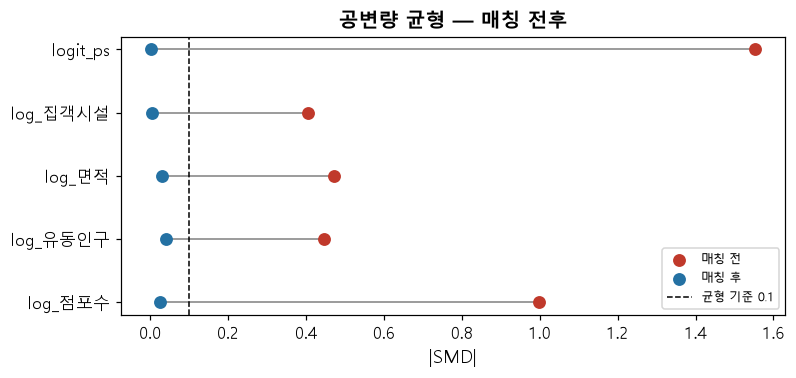

모든 공변량 |SMD| < 0.1 : 예 — 비교 조건이 맞았으므로 아래 ATT를 읽을 수 있음


In [36]:
def smd_of(a, b_):
    return (a.mean() - b_.mean()) / np.sqrt((a.var() + b_.var()) / 2)

rows = []
for c_ in PS_COV + ["logit_ps"]:
    pre = smd_of(gm2.loc[gm2["처리"] == 1, c_], gm2.loc[gm2["처리"] == 0, c_])
    post = smd_of(gm2.loc[ti, c_], gm2.loc[ci, c_])
    rows.append({"공변량": c_, "매칭 전 SMD": round(pre, 3), "매칭 후 SMD": round(post, 3),
                 "감소폭": round(abs(pre) - abs(post), 3),
                 "판정": "균형" if abs(post) < .1 else ("불균형" if abs(post) < .25 else "심각한 불균형")})
bal = pd.DataFrame(rows).set_index("공변량")
display(bal)

fig, ax = plt.subplots(figsize=(7.4, 3.6))
yy = np.arange(len(bal))
ax.scatter(bal["매칭 전 SMD"].abs(), yy, s=55, c="#c0392b", label="매칭 전")
ax.scatter(bal["매칭 후 SMD"].abs(), yy, s=55, c="#2471a3", label="매칭 후")
for i_ in yy:
    ax.plot([abs(bal["매칭 전 SMD"].iloc[i_]), abs(bal["매칭 후 SMD"].iloc[i_])], [i_, i_],
            c="gray", lw=1, zorder=0)
ax.axvline(0.1, ls="--", c="k", lw=1, label="균형 기준 0.1")
ax.set_yticks(yy); ax.set_yticklabels(bal.index); ax.set_xlabel("|SMD|")
ax.set_title("공변량 균형 — 매칭 전후", weight="bold"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "psm_balance.png", dpi=130); plt.show()

ok = (bal["매칭 후 SMD"].abs() < .1).all()
print(f"모든 공변량 |SMD| < 0.1 : {'예 — 비교 조건이 맞았으므로 아래 ATT를 읽을 수 있음' if ok else '아니오 — 아래 ATT를 신뢰할 수 없음'}")

### ATT — 조건을 맞춘 뒤의 격차

**ATT(처리군에 대한 평균 처리효과)** = 짝지은 쌍에서 «처리군 순감소율 − 대조군 순감소율».

- **검정은 McNemar** — 짝지은 이진 결과이므로 독립표본 검정을 쓸 수 없음.
  두 값이 **다른 쌍만** 세는 검정이고, 같은 쌍은 어느 쪽이 위험한지에 정보를 주지 않으므로 빠짐
- **신뢰구간은 상권 단위 클러스터 부트스트랩** — 같은 상권의 여러 업종 칸은 독립이 아님.
  칸을 개별로 다시 뽑으면 구간이 실제보다 좁게 나오므로 **상권을 묶어서** 다시 뽑음


In [37]:
yt = gm2.loc[ti, "y"].values; yc = gm2.loc[ci, "y"].values
att = yt.mean() - yc.mean()
p1 = gm2.loc[gm2["처리"] == 1, "y"].mean(); p0 = gm2.loc[gm2["처리"] == 0, "y"].mean()
raw = p1 - p0

b_ = int(((yt == 1) & (yc == 0)).sum())
c_ = int(((yt == 0) & (yc == 1)).sum())
mc = binomtest(b_, b_ + c_, 0.5) if (b_ + c_) else None

print(f"매칭 전 단순 격차   {p1:.4f} − {p0:.4f} = {raw:+.4f}  ({raw*100:+.2f}%p)")
print(f"매칭 후 ATT        {yt.mean():.4f} − {yc.mean():.4f} = {att:+.4f}  ({att*100:+.2f}%p)")
print()
if mc:
    print(f"McNemar  불일치 쌍 {b_+c_:,}개 (처리군만 순감소 {b_:,} · 대조군만 순감소 {c_:,})")
    print(f"         p = {plain(mc.pvalue)}  → {'유의' if mc.pvalue < .05 else '비유의'}")
    print(f"         일치 쌍 {len(pairs)-b_-c_:,}개는 검정에 쓰이지 않음")

rng_ = np.random.default_rng(0)
clus = gm2.loc[ti, "상권_코드"].values
uniq = np.unique(clus)
by_clus = {u: np.where(clus == u)[0] for u in uniq}
boot = []
for _ in range(500):
    pick = rng_.choice(uniq, len(uniq), replace=True)
    m = np.concatenate([by_clus[u] for u in pick])
    boot.append(yt[m].mean() - yc[m].mean())
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"\n클러스터 부트스트랩 95% CI  [{lo*100:+.2f}%p, {hi*100:+.2f}%p]  (상권 {len(uniq):,}개 · 500회)")
print(f"0을 포함하는가: {'예 — 방향을 단정할 수 없음' if lo < 0 < hi else '아니오 — 방향이 일관됨'}")

print()
if raw * att < 0:
    print("→ 단순 격차와 ATT의 **부호가 뒤집혔음.** 단순 비교에서 보였던 격차는 업종 차이가 아니라")
    print("  규모·입지 차이(교란)를 읽은 것이었다는 뜻임. 5-4의 «심각한 불균형»이 이 결과의 원인임.")
elif abs(att) < abs(raw):
    print(f"→ 조건을 맞추자 격차가 {abs(raw)*100:.2f}%p → {abs(att)*100:.2f}%p 로 줄었음.")
    print(f"  단순 격차의 {(1-abs(att)/abs(raw))*100:.0f}% 가 교란이었다는 뜻임.")
else:
    print("→ 조건을 맞춘 뒤에도 격차가 유지되거나 커졌음. 업종 자체의 효과로 볼 근거가 생김.")

매칭 전 단순 격차   0.2527 − 0.2288 = +0.0238  (+2.38%p)
매칭 후 ATT        0.2298 − 0.2844 = -0.0546  (-5.46%p)

McNemar  불일치 쌍 2,613개 (처리군만 순감소 1,120 · 대조군만 순감소 1,493)
         p = 0.000000000000311  → 유의
         일치 쌍 4,223개는 검정에 쓰이지 않음

클러스터 부트스트랩 95% CI  [-6.77%p, -3.81%p]  (상권 866개 · 500회)
0을 포함하는가: 아니오 — 방향이 일관됨

→ 단순 격차와 ATT의 **부호가 뒤집혔음.** 단순 비교에서 보였던 격차는 업종 차이가 아니라
  규모·입지 차이(교란)를 읽은 것이었다는 뜻임. 5-4의 «심각한 불균형»이 이 결과의 원인임.


### 민감도 분석 — 설계를 바꿔도 결론이 같은가

매칭에는 임의로 정하는 값이 몇 개 있음(캘리퍼 폭, 복원 여부). 결론이 그 선택에 좌우된다면
그것은 결론이 아니라 **설계의 산물**임. 그래서 바꿔 보고 부호와 크기가 유지되는지 확인함.


In [38]:
sens = [{"설계": "매칭 없음(단순 격차)", "쌍/칸 수": len(gm2), "ATT(%p)": round(raw*100, 2)}]
for cm in [0.1, 0.2, 0.3, 0.5]:
    pr = match(gm2, cm * gm2["logit_ps"].std())
    if not pr: continue
    a = gm2.loc[[p[0] for p in pr], "y"].values; b2 = gm2.loc[[p[1] for p in pr], "y"].values
    sens.append({"설계": f"캘리퍼 {cm}×SD", "쌍/칸 수": len(pr), "ATT(%p)": round((a.mean()-b2.mean())*100, 2)})
pr = match(gm2, CALIPER, replace=True)
a = gm2.loc[[p[0] for p in pr], "y"].values; b2 = gm2.loc[[p[1] for p in pr], "y"].values
sens.append({"설계": "복원 허용", "쌍/칸 수": len(pr), "ATT(%p)": round((a.mean()-b2.mean())*100, 2)})

SENS = pd.DataFrame(sens).set_index("설계")
display(SENS)
m_only = SENS.drop(index="매칭 없음(단순 격차)")["ATT(%p)"]
same = (m_only > 0).all() or (m_only < 0).all()
print(f"매칭 설계 {len(m_only)}종의 ATT 범위 {m_only.min():+.2f} ~ {m_only.max():+.2f}%p")
print(f"부호 일치: {'예 — 방향은 설계의 산물이 아님' if same else '아니오 — 방향을 주장할 수 없음'}")
print(f"매칭 없음과의 차이: {raw*100:+.2f}%p → {m_only.mean():+.2f}%p (매칭 평균)")

,쌍/칸 수,ATT(%p)
설계,,
매칭 없음(단순 격차),34647,2.38
캘리퍼 0.1×SD,6836,-5.59
캘리퍼 0.2×SD,6836,-5.46
캘리퍼 0.3×SD,6838,-5.47
캘리퍼 0.5×SD,6841,-5.47
복원 허용,9943,-4.43


매칭 설계 5종의 ATT 범위 -5.59 ~ -4.43%p
부호 일치: 예 — 방향은 설계의 산물이 아님
매칭 없음과의 차이: +2.38%p → -5.28%p (매칭 평균)


## 5-8. 사후검정 — 어느 쌍이 다른가 (Dunn's test)

Kruskal-Wallis는 «어딘가 차이가 있다»까지만 말함. 그룹이 넷이면 가능한 쌍이 여섯인데,
그중 어느 쌍이 다른지는 알려주지 않음. **어느 쌍이 다른지**는 사후검정이 답함.

**Dunn's test** — Kruskal-Wallis와 같은 순위를 그대로 써서 쌍마다 z를 냄.
그룹별로 다시 검정하는 것이 아니라 **전체 순위 하나를 공유**하므로 Kruskal 결과와 정합적임.
쌍의 개수만큼 Bonferroni 보정함(4그룹이면 6배, 25그룹이면 300배).

**동순위 보정을 넣음** — 순감소비율은 `0`, `1/12`, `2/12` … 같은 값이 반복되어 동순위가 많음.
보정 없이 계산하면 분산이 과대추정되어 유의성이 실제보다 낮게 나옴.

표에는 p-value와 **어느 쪽이 높은지**를 함께 담음 — p만 있으면 방향을 알 수 없음.


In [39]:
def dunn(df, group, label="순감소비율", min_n=20):
    g = df[[group, label]].dropna()
    vc = g[group].value_counts()
    g = g[g[group].isin(vc[vc >= min_n].index)]
    g = g.assign(_r=rankdata(g[label].values))
    N = len(g); ks = list(g.groupby(group)[label].median().sort_values().index)
    st = g.groupby(group)["_r"].agg(["mean", "size"])
    _, cnt = np.unique(g[label].values, return_counts=True)
    ties = (cnt ** 3 - cnt).sum()
    sigma2 = (N * (N + 1) / 12) - ties / (12 * (N - 1))
    m = len(ks) * (len(ks) - 1) / 2
    P = pd.DataFrame(1.0, index=ks, columns=ks)
    recs = []
    for i_ in range(len(ks)):
        for j_ in range(i_ + 1, len(ks)):
            a, b3 = ks[i_], ks[j_]
            se = np.sqrt(sigma2 * (1 / st.loc[a, "size"] + 1 / st.loc[b3, "size"]))
            z = (st.loc[b3, "mean"] - st.loc[a, "mean"]) / se
            p = min(1.0, 2 * (1 - norm.cdf(abs(z))) * m)
            P.loc[a, b3] = P.loc[b3, a] = round(p, 4)
            recs.append({"쌍": f"{a} ↔ {b3}", "z": round(z, 2), "p(보정)": round(p, 4),
                         "유의": p < .05, "더 높은 쪽": b3 if z > 0 else a})
    return P, pd.DataFrame(recs).sort_values("p(보정)"), st, ks

print("상권유형 — 순위 중앙값 낮은 순으로 정렬")
P_t, R_t, st_t, ks_t = dunn(cell, "상권유형")
med = cell.groupby("상권유형")["순감소비율"].agg(["median", "mean", "size"]).loc[ks_t].round(4)
display(med)
display(P_t)
display(R_t.set_index("쌍"))
print(f"유의한 쌍 {int(R_t['유의'].sum())}/{len(R_t)}개 (Bonferroni 보정 후 α=0.05)")

상권유형 — 순위 중앙값 낮은 순으로 정렬


,median,mean,size
상권유형,,,
전통시장,0.1667,0.2176,775
골목상권,0.25,0.2282,2922
발달상권,0.25,0.2894,1932
관광특구,0.3333,0.3779,58


,전통시장,골목상권,발달상권,관광특구
전통시장,1,0.321,0,0
골목상권,0.321,1,0,0
발달상권,0,0,1,0.0003
관광특구,0,0,0.0003,1


,z,p(보정),유의,더 높은 쪽
쌍,,,,
전통시장 ↔ 발달상권,10.41,0,True,발달상권
전통시장 ↔ 관광특구,7.23,0,True,관광특구
골목상권 ↔ 발달상권,12.44,0,True,발달상권
골목상권 ↔ 관광특구,6.84,0,True,관광특구
발달상권 ↔ 관광특구,4.07,0.0003,True,관광특구
전통시장 ↔ 골목상권,1.93,0.321,False,골목상권


유의한 쌍 5/6개 (Bonferroni 보정 후 α=0.05)


In [40]:
# 자치구는 분석 단위가 아니므로 쌍별 지도까지 그리지 않고, 요약값만 남김.
# 이 값이 «위험을 말할 단위가 자치구가 아니라 상권»이라는 판단의 근거임
P_g, R_g, st_g, ks_g = dunn(cell[cell["상권유형"] == TARGET_TYPE], "자치구")
n_sig = int(R_g["유의"].sum())
print(f"골목상권 안에서 자치구 {len(ks_g)}개 · 가능한 쌍 {len(R_g)}개 · "
      f"유의한 쌍 {n_sig}개 ({n_sig/len(R_g):.1%})")
print(f"  순감소 수준이 낮은 편 : {', '.join(ks_g[:5])}")
print(f"  순감소 수준이 높은 편 : {', '.join(ks_g[-5:])}")
print()
print("→ 유의한 쌍의 비율이 매우 낮음. 자치구 대부분이 서로 구분되지 않는 중간군을 이룸.")
print("  자치구를 범주로 묶어도 그 안에서 얻을 정보가 적다는 뜻이며,")
print("  이 분석의 단위를 상권 × 업종으로 잡은 판단을 뒷받침함.")
print("  같은 자치구 안에서도 상권마다 사정이 다르므로 행정 경계로 대응하면 위험한 곳을 놓침.")

골목상권 안에서 자치구 25개 · 가능한 쌍 300개 · 유의한 쌍 3개 (1.0%)
  순감소 수준이 낮은 편 : 서초구, 동작구, 양천구, 종로구, 중구
  순감소 수준이 높은 편 : 노원구, 관악구, 송파구, 은평구, 중랑구

→ 유의한 쌍의 비율이 매우 낮음. 자치구 대부분이 서로 구분되지 않는 중간군을 이룸.
  자치구를 범주로 묶어도 그 안에서 얻을 정보가 적다는 뜻이며,
  이 분석의 단위를 상권 × 업종으로 잡은 판단을 뒷받침함.
  같은 자치구 안에서도 상권마다 사정이 다르므로 행정 경계로 대응하면 위험한 곳을 놓침.


---
# 6. 산출물

| 파일 | 내용 |
|---|---|
| `data/processed/02_merged.pkl` | 결합만 끝난 상태 (라벨 이전) |
| `data/processed/03_panel.pkl` | 라벨·파생변수까지 완료된 분석 패널 |
| `data/processed/04_model_input.csv` | 다음 노트북이 바로 읽는 모델 입력 |
| `figures/*.png` | 탐색 그림 |

다음 노트북에서 할 일을 여기서 고정해 둠.

1. **시간순 분할** — 예측 대상 분기 기준으로 학습 2023Q2~2025Q3 / 검증 2025Q4 / 테스트 2026Q1.
   피처는 각각 그 앞 분기에서 읽음. 테스트는 마지막에 한 번만 사용
2. **기준선 통과 확인** — 5-1의 네 기준선과 5-2의 구간별 값을 모델에 그대로 다시 적용
3. **집객시설 정리** — 지금 남긴 항목 전부를 넣고 학습한 뒤, 기여도와 규모 상관을 함께 보고 추림
4. **후보 변수 재확인** — 3-3 에서 통과·탈락한 변수를 모델에서 다시 확인
5. **2단계 모형 비교** — `P(사건) × P(순감소 | 사건)` 을 단일 모형과 같은 검증셋에서 비교
6. **위험도 예측과 지도 표출**


In [41]:
KEEP = (["기준_년분기_코드", "분기idx", "상권_코드", "상권_코드_명", "상권유형", "자치구",
         "행정동_코드", "행정동", "서비스_업종_코드", "서비스_업종_코드_명",
         "엑스좌표_값", "와이좌표_값", "영역_면적",
         "전체_점포_수", "일반_점포_수", "프랜차이즈_점포_수", "개업_점포_수", "폐업_점포_수",
         "상권_전체점포", "총_유동인구_수", "당월_매출_금액", "당월_매출_건수",
         "역세권", "상권_변화_지표", "기준선_위험",
         "운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망",
         "업종점포비중", "해당업종_점포밀도", "요식업_점포밀도", "프랜차이즈비율", "점포당매출", "매출결측",
         "log_점포수", "log_유동인구", "log_면적", "log_해당업종밀도", "log_요식업밀도", "log_점포당매출",
         "순감소_현재", "사건_현재", "규모구간", "다음상태", "사건_다음", "y"]
        + FAC_KEEP + [c for c in d.columns if c.startswith("밀도_")])
KEEP = [c for c in dict.fromkeys(KEEP) if c in d.columns]
out = d[KEEP].copy()
out.to_csv(PROC / "04_model_input.csv", index=False, encoding="utf-8-sig")
print(f"[저장] 04_model_input.csv  {out.shape}")
print(f"  분기 {out['기준_년분기_코드'].nunique()}개 · 상권 {out['상권_코드'].nunique():,}개 "
      f"· 업종 {out['서비스_업종_코드_명'].nunique()}개")
print(f"  양성률 {out['y'].mean():.1%} · 집객시설 항목 {len(FAC_KEEP)}개 · 후보 변수 4개")
print("\n컬럼 목록")
print("  " + ", ".join(KEEP))

[저장] 04_model_input.csv  (67475, 71)
  분기 12개 · 상권 1,422개 · 업종 10개
  양성률 25.5% · 집객시설 항목 12개 · 후보 변수 4개

컬럼 목록
  기준_년분기_코드, 분기idx, 상권_코드, 상권_코드_명, 상권유형, 자치구, 행정동_코드, 행정동, 서비스_업종_코드, 서비스_업종_코드_명, 엑스좌표_값, 와이좌표_값, 영역_면적, 전체_점포_수, 일반_점포_수, 프랜차이즈_점포_수, 개업_점포_수, 폐업_점포_수, 상권_전체점포, 총_유동인구_수, 당월_매출_금액, 당월_매출_건수, 역세권, 상권_변화_지표, 기준선_위험, 운영_영업_개월_평균, 운영개월_서울대비, 외식물가지수, 외식지출전망, 업종점포비중, 해당업종_점포밀도, 요식업_점포밀도, 프랜차이즈비율, 점포당매출, 매출결측, log_점포수, log_유동인구, log_면적, log_해당업종밀도, log_요식업밀도, log_점포당매출, 순감소_현재, 사건_현재, 규모구간, 다음상태, 사건_다음, y, 버스_정거장_수, 약국_수, 관공서_수, 은행_수, 지하철_역_수, 유치원_수, 숙박_시설_수, 일반_병원_수, 슈퍼마켓_수, 극장_수, 대학교_수, 종합병원_수, 밀도_버스_정거장, 밀도_약국, 밀도_관공서, 밀도_은행, 밀도_지하철_역, 밀도_유치원, 밀도_숙박_시설, 밀도_일반_병원, 밀도_슈퍼마켓, 밀도_극장, 밀도_대학교, 밀도_종합병원


---
## 정리

- 요식업 10종 · 골목상권 중심의 **상권 × 업종 × 분기** 패널을 만들고, 다음 분기 순감소 라벨을 붙임.
- `y=0`이 **「변화 없음」**과 **「변화 있었으나 줄지 않음」**의 합이라는 점을 분해해 보였고,
  **상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높다**는 것을 규모 구간별로 측정해 남김.
  미래 사건 여부로는 표본을 고를 수 없으므로 이 칸들을 **버리지 않고** 유지함.
- 규모를 **밀도 · 면적 · 비중** 세 축으로 나누어 담아, 어느 축이 위험을 만드는지 구분할 수 있게 함.
- 기준선에 **«점포 수»** 를 포함시키고 **점포 수 구간별 값**을 함께 재, 다음 노트북의 모델이
  «규모를 고른 것» 인지 «위험을 읽은 것» 인지 판정할 수 있는 기준을 만들어 둠.
- **전국 단위 경제지표는 쓰지 않음.** 한 분기 안에서 모든 상권이 같은 값이 되어
  상권 사이의 순위를 바꾸지 못하므로, 이 과제의 평가 방식에서는 기여할 수 없음.
